In [28]:
import pandas as pd

# Load the dataset
file_path = 'ECGCvdata.csv'
data = pd.read_csv(file_path)

In [29]:
data.describe()

,RECORD,hbpermin,Pseg,PQseg,QRSseg,QRseg,QTseg,RSseg,STseg,Tseg,...,SDSD,RMSSD,QRSarea,QRSperi,PQslope,QRslope,RSslope,STslope,NN50,pNN50
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,432.000000,431.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,81.893980,0.060902,0.078099,0.048238,0.024437,0.141541,0.023800,0.093303,0.102714,...,42.484060,199.417894,7.675047,23.915846,-0.071647,0.141737,-0.150496,0.041659,6.442500,8.112425
std,346.554469,19.324351,0.009453,0.019897,0.034649,0.017501,0.029225,0.017175,0.013332,0.022594,...,105.722123,112.292014,8.452832,25.070324,0.049705,0.073086,0.077532,0.026456,7.748445,10.325033
min,1.000000,12.857143,0.021556,0.044526,0.000000,0.000000,0.098761,0.000000,0.052338,0.034936,...,0.800624,61.711281,0.000000,0.000000,-0.219938,0.028660,-0.315525,0.008183,0.000000,0.000000
25%,300.750000,67.563000,0.053943,0.060344,0.015101,0.007804,0.116016,0.007143,0.089423,0.090046,...,4.060951,123.147741,0.000000,0.124186,-0.106660,0.082613,-0.240304,0.023853,1.000000,0.613497
50%,600.500000,79.872000,0.060642,0.075184,0.044692,0.022676,0.137019,0.021965,0.097825,0.099210,...,11.265829,183.603851,5.228299,19.904060,-0.058518,0.108418,-0.116241,0.034460,3.000000,3.680982
75%,900.250000,96.000000,0.066849,0.095190,0.083032,0.041915,0.166314,0.041097,0.101200,0.112408,...,44.785825,248.101035,14.355389,46.194325,-0.027685,0.229659,-0.087565,0.049778,10.000000,12.883436
max,1200.000000,160.500000,0.095317,0.145577,0.120160,0.065278,0.211111,0.058333,0.138444,0.198413,...,1725.927603,1478.488460,33.131007,86.577082,-0.005427,0.270786,-0.027983,0.164633,37.000000,52.727273


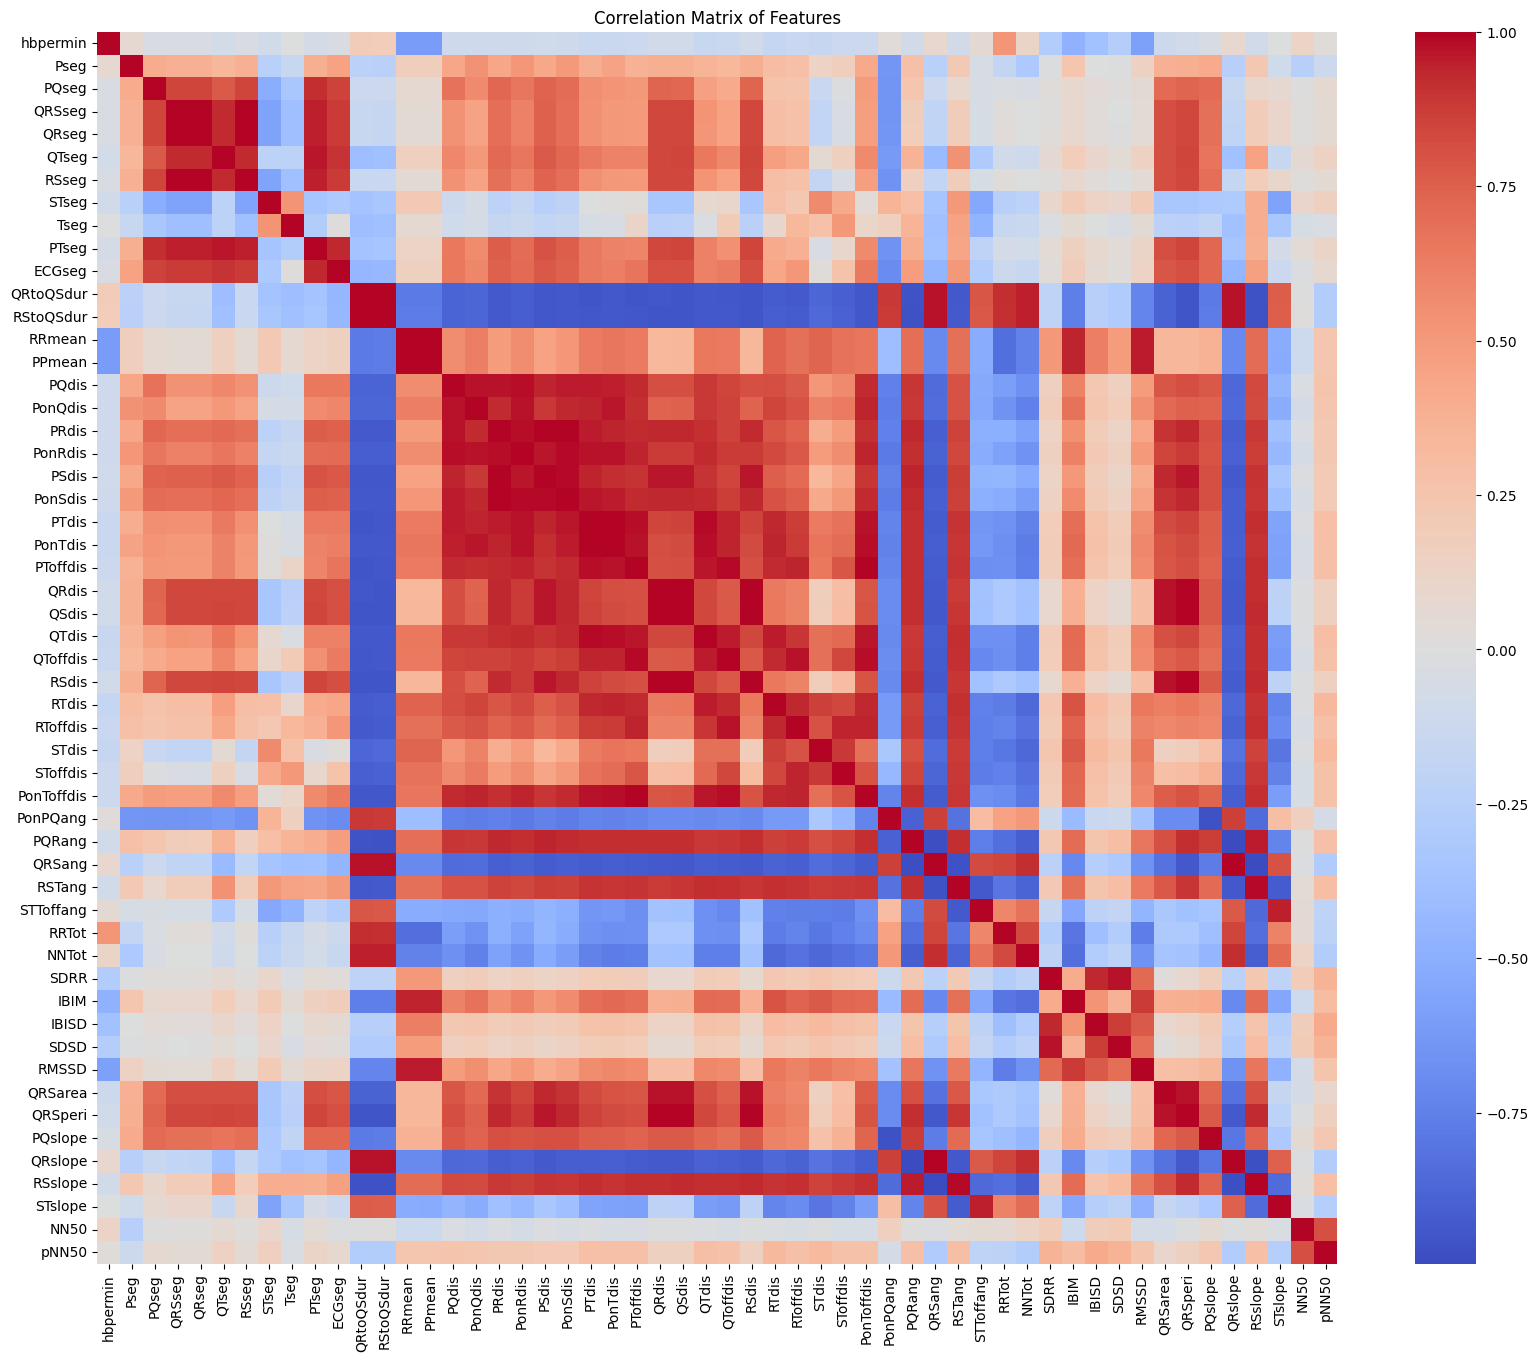

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

## Correlation matrix
correlation_matrix = data.iloc[:, 1:55].corr()

# Plotting the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

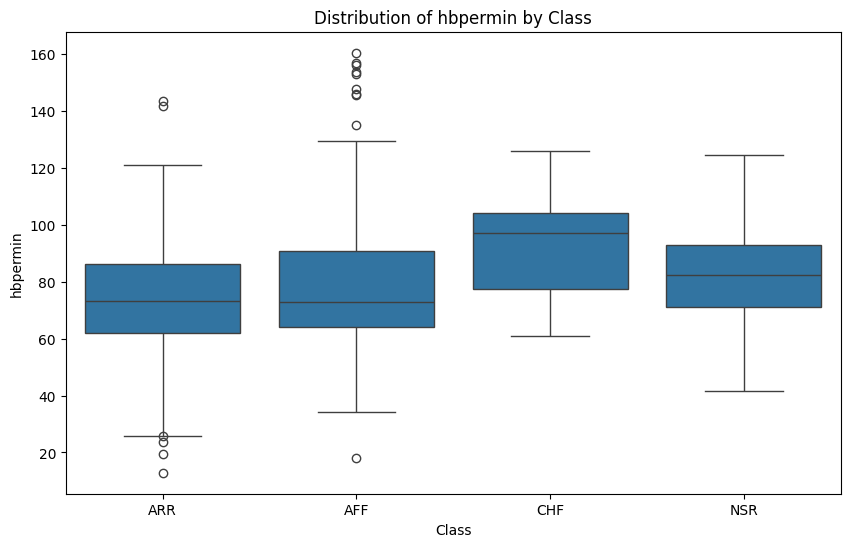

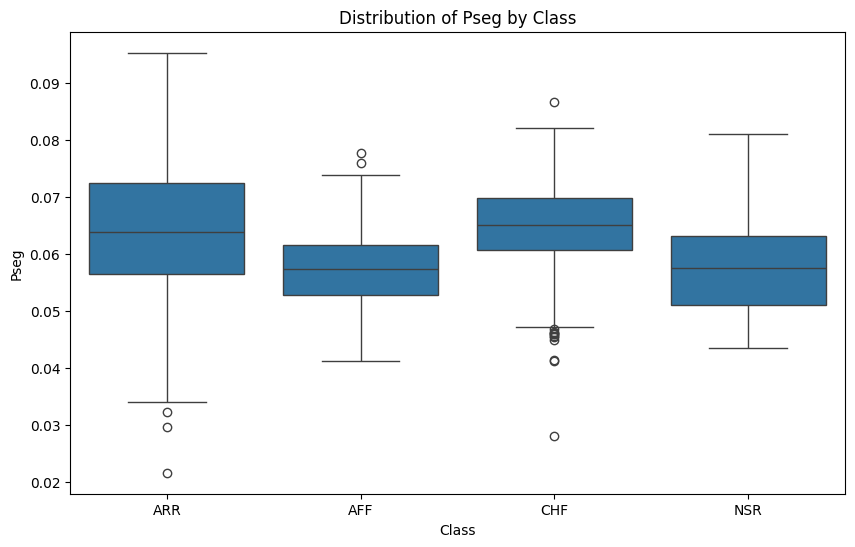

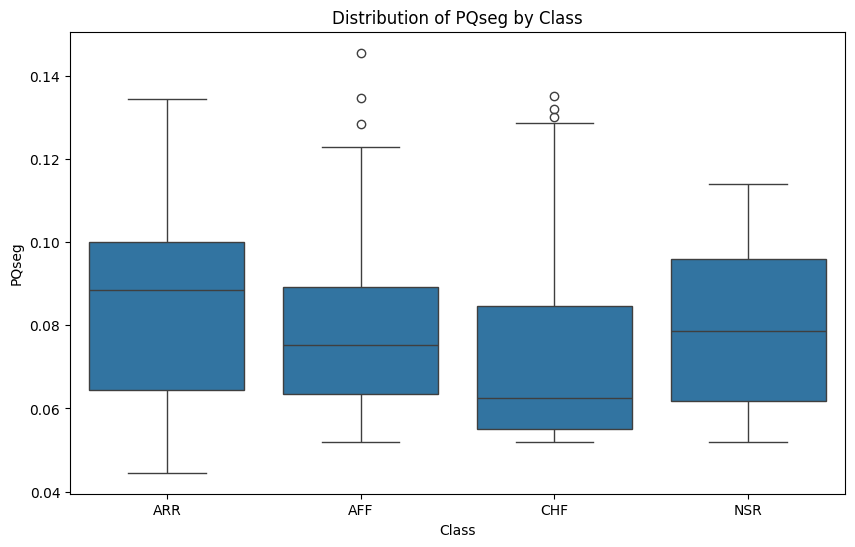

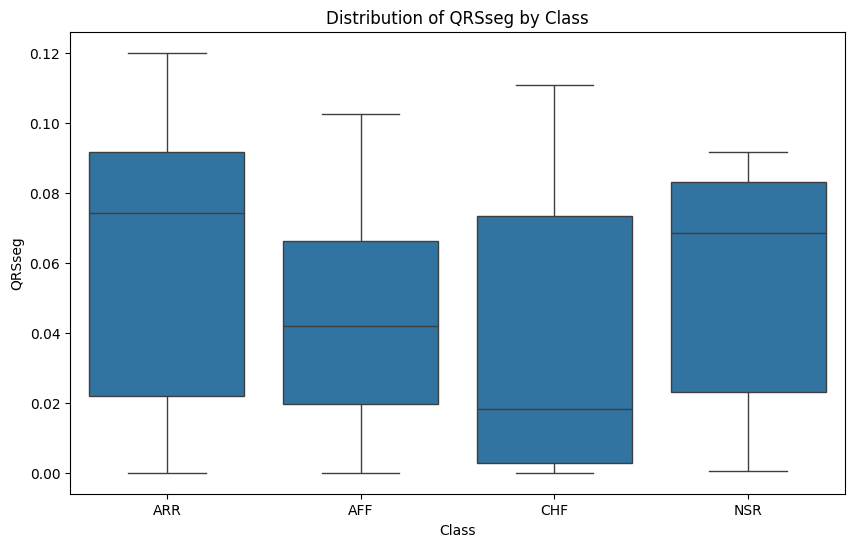

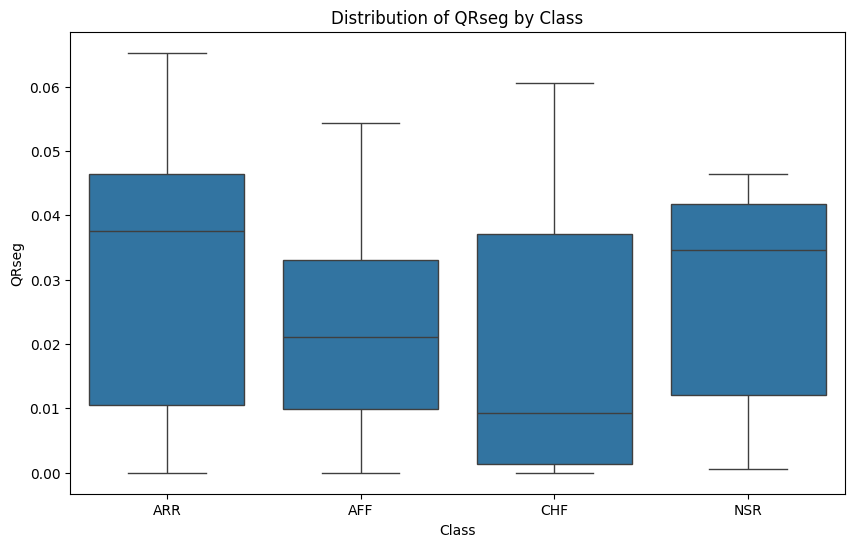

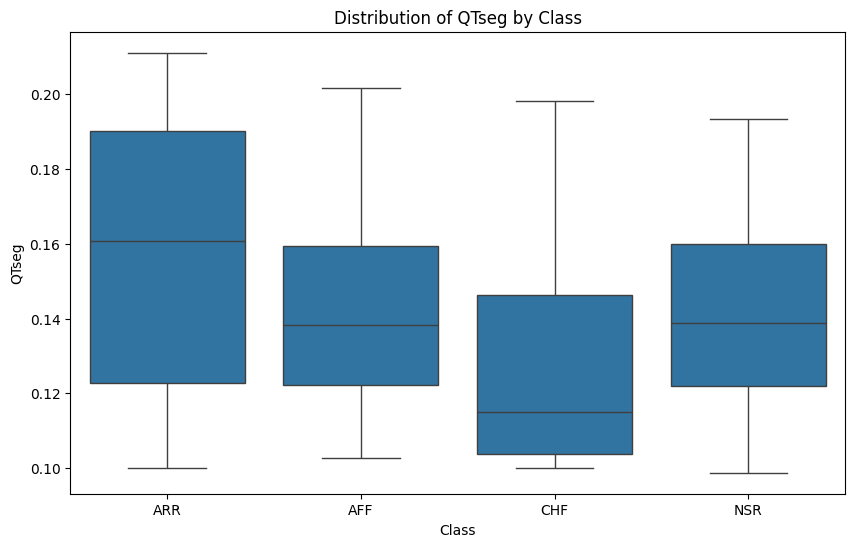

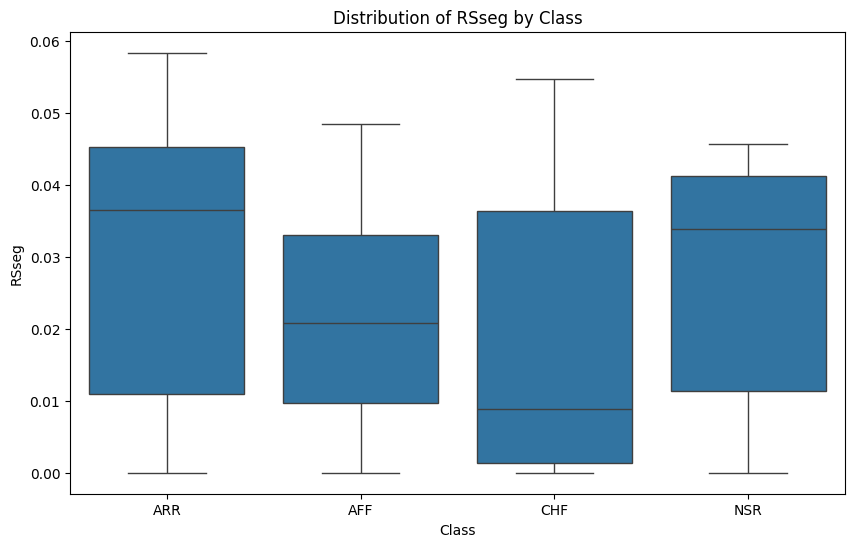

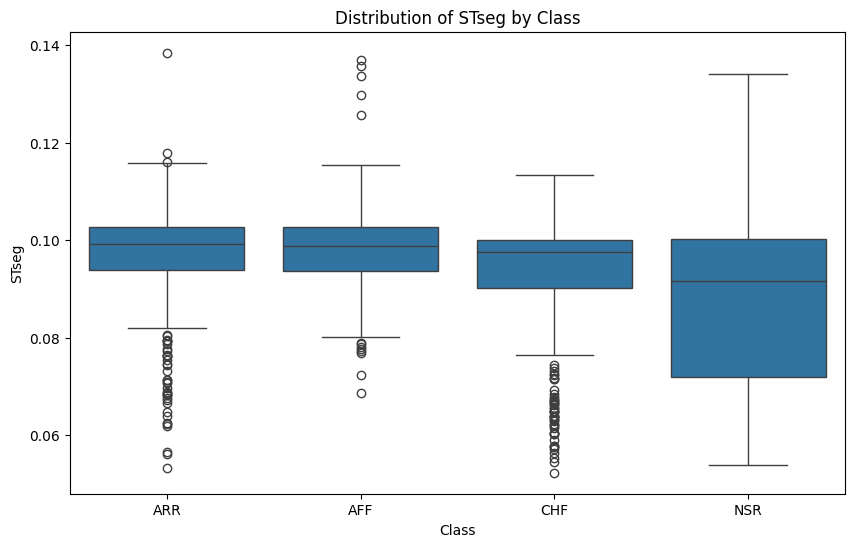

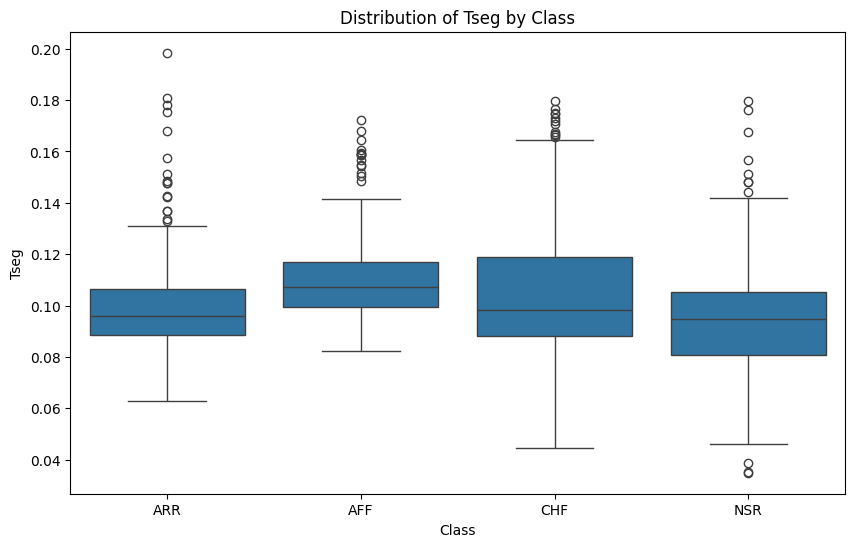

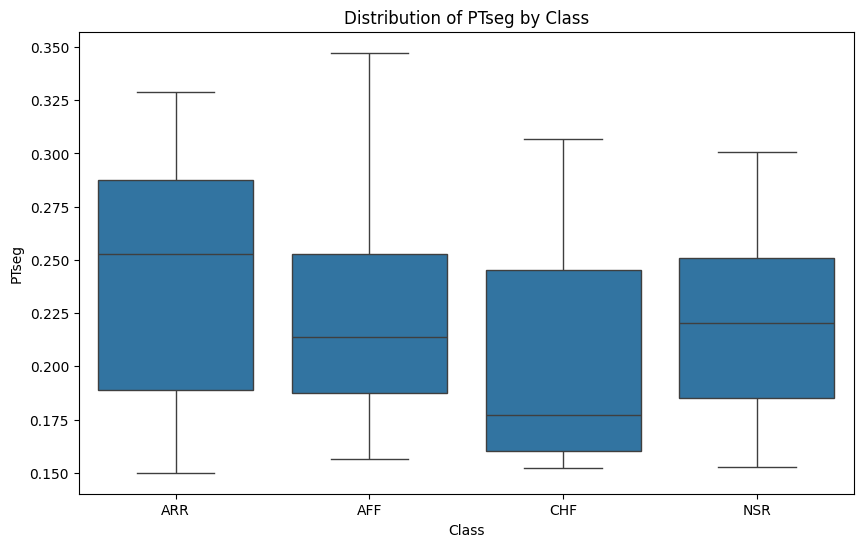

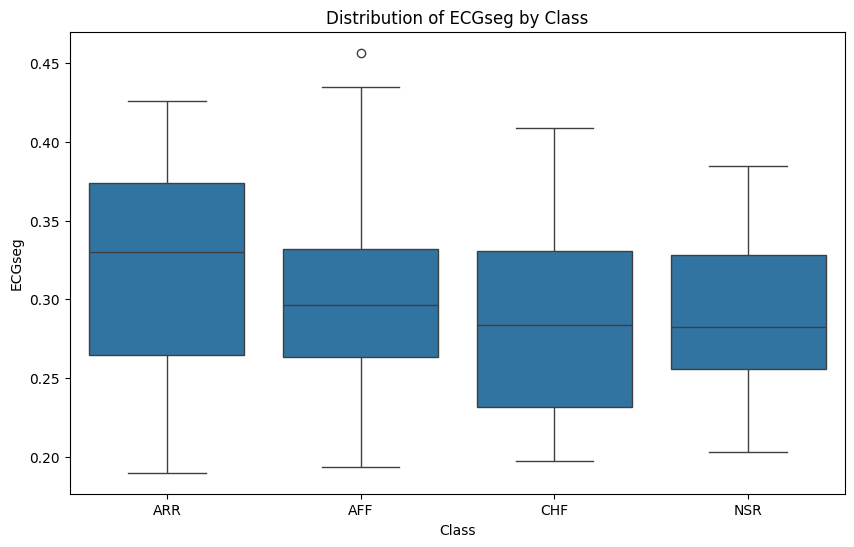

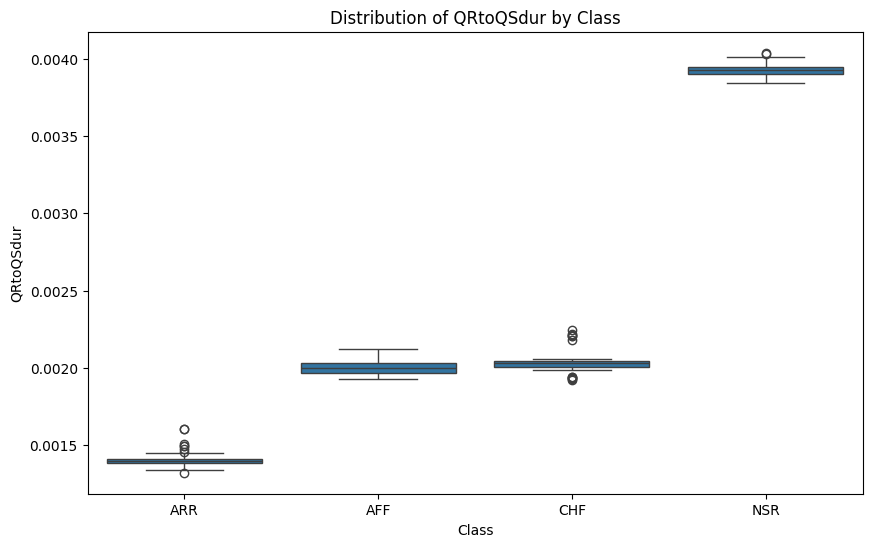

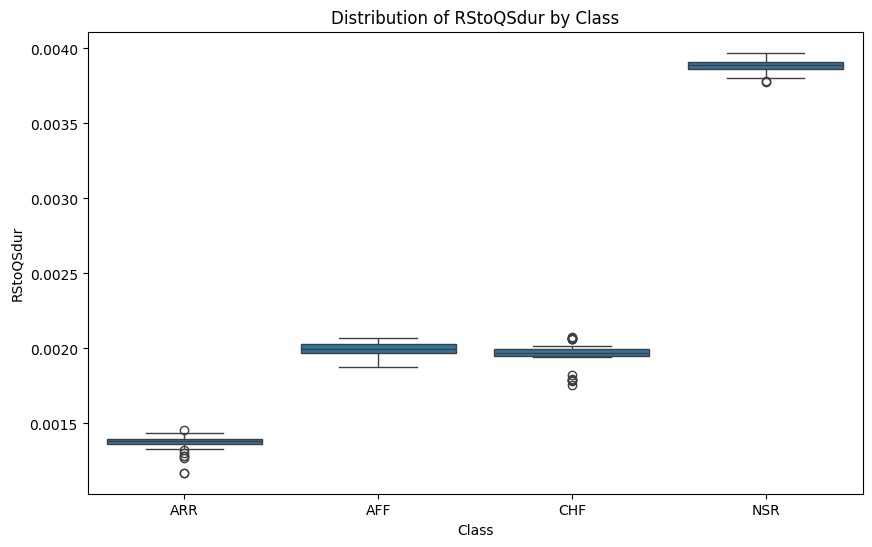

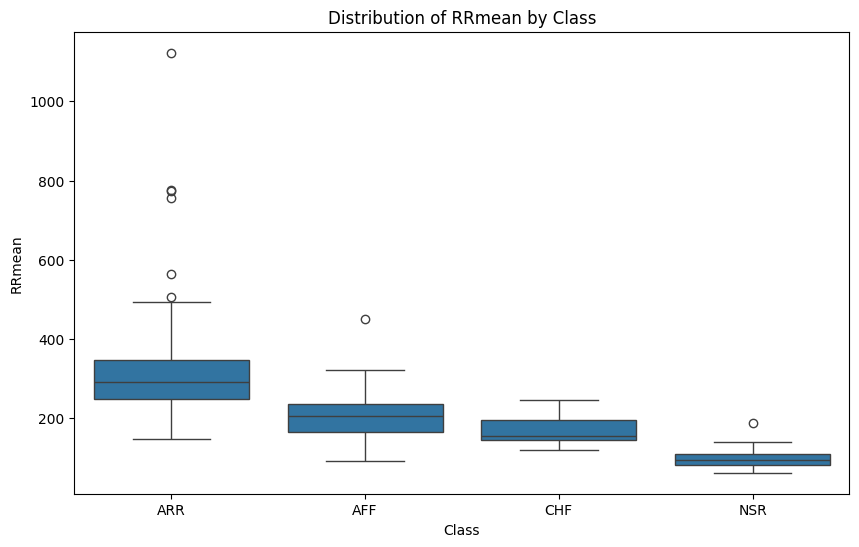

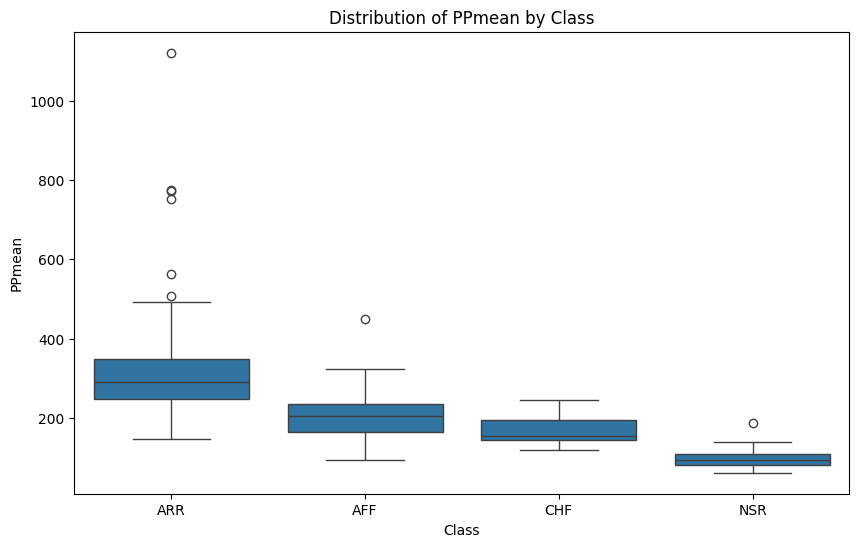

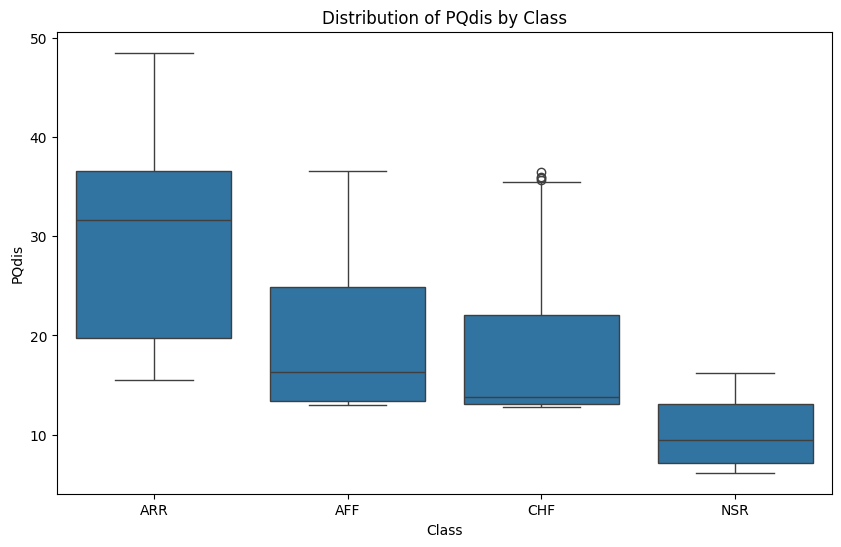

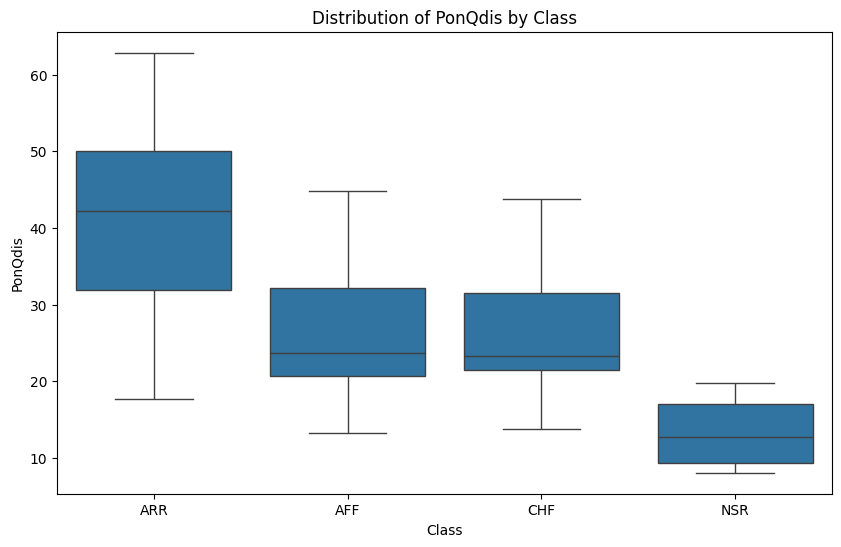

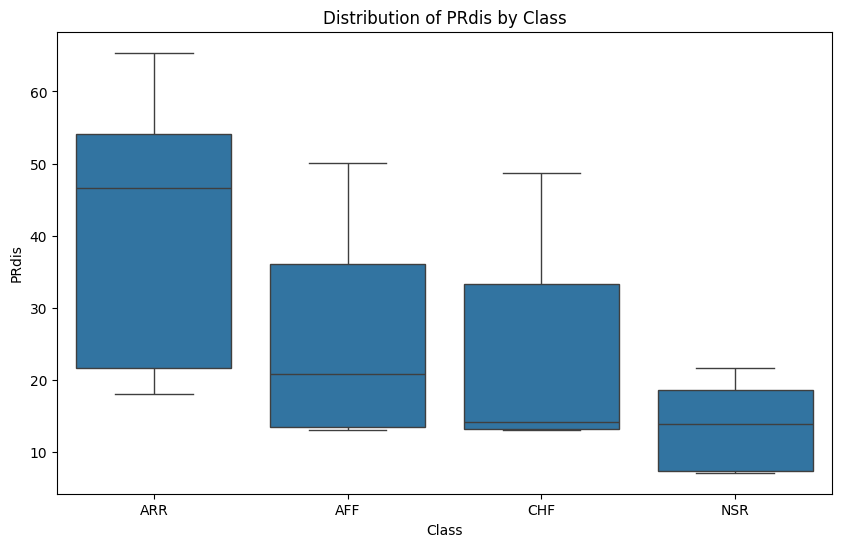

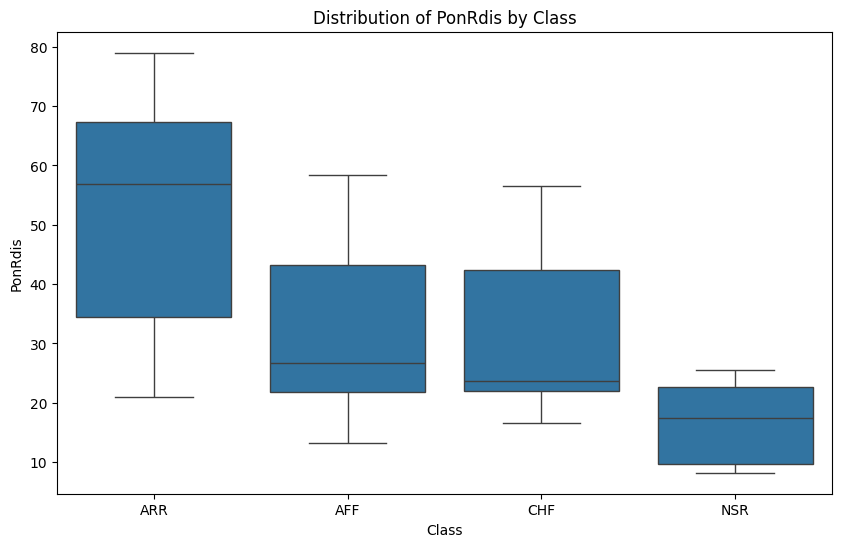

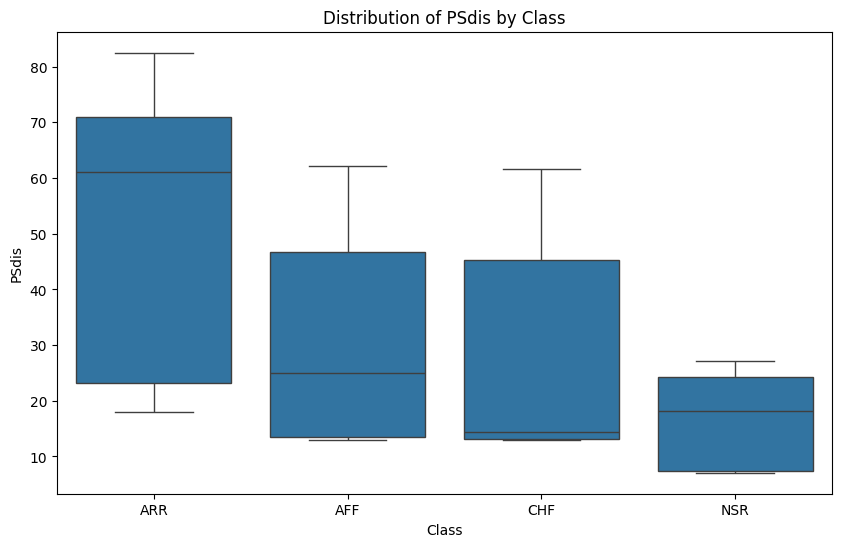

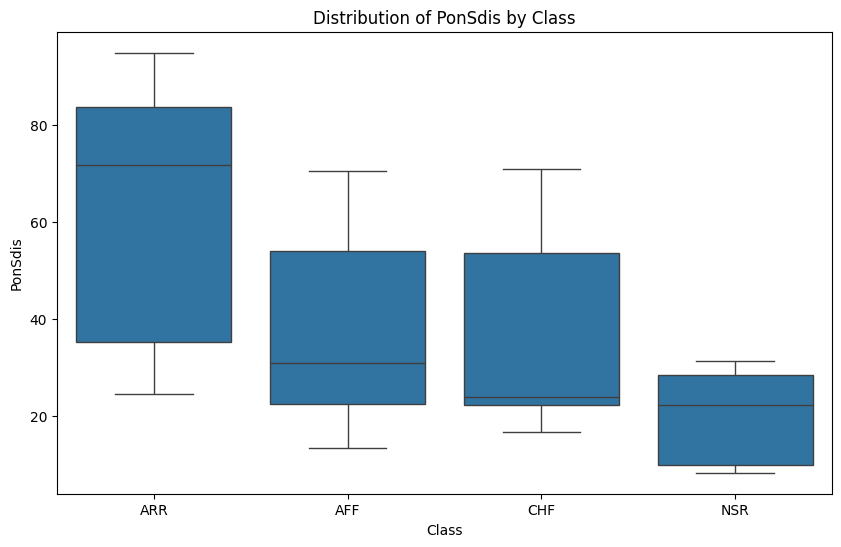

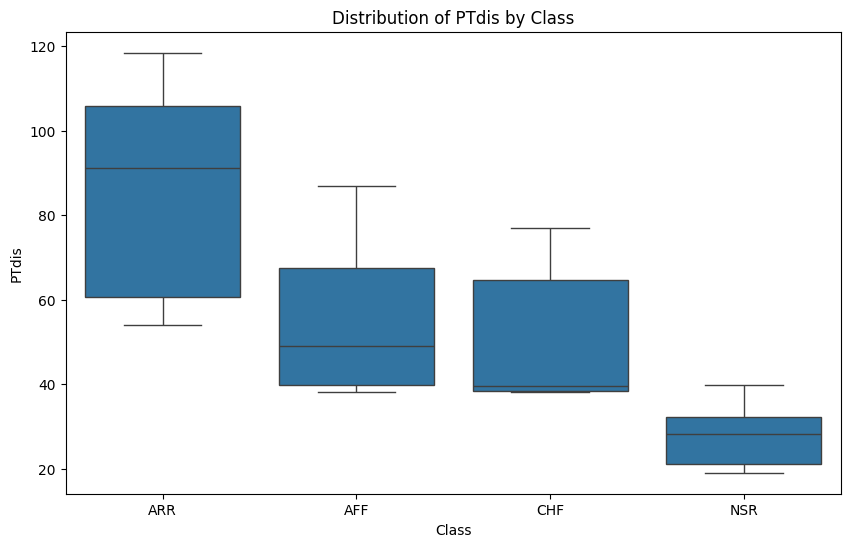

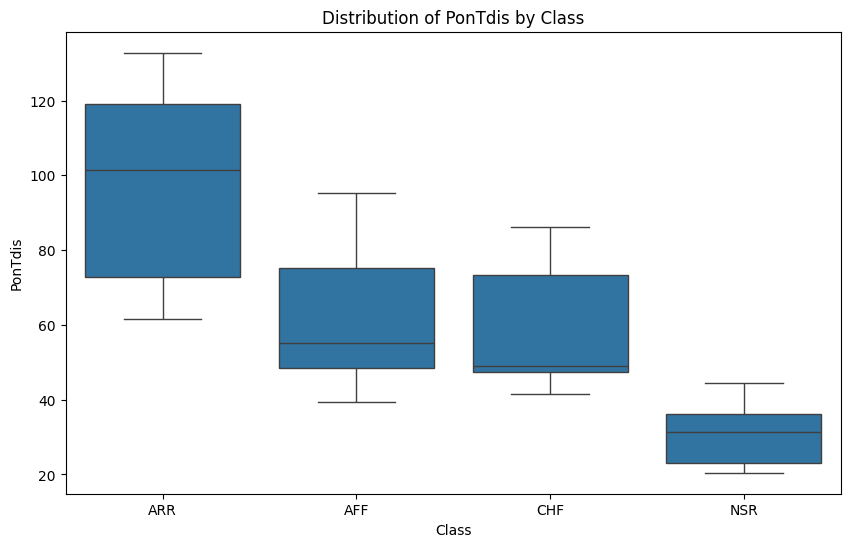

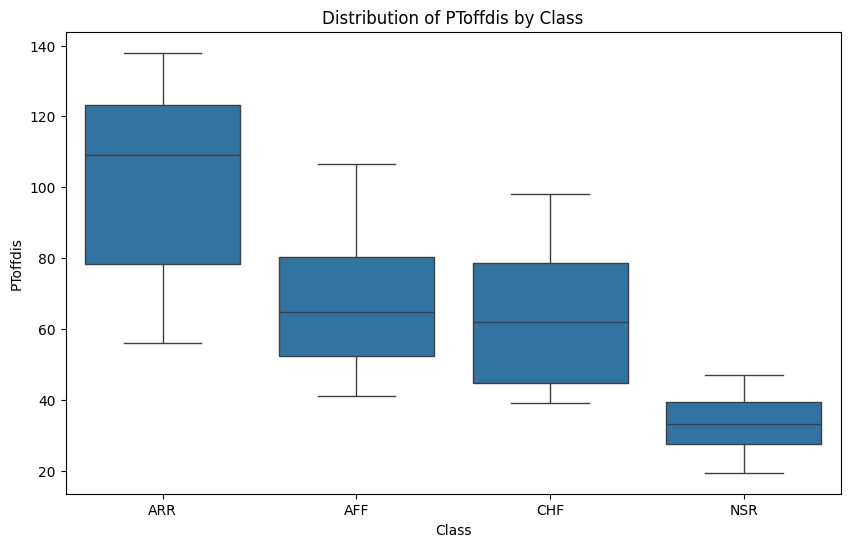

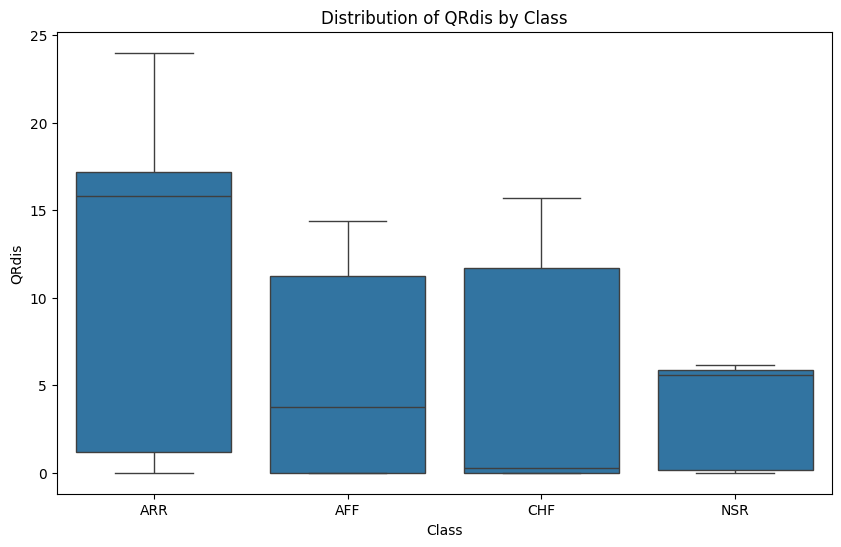

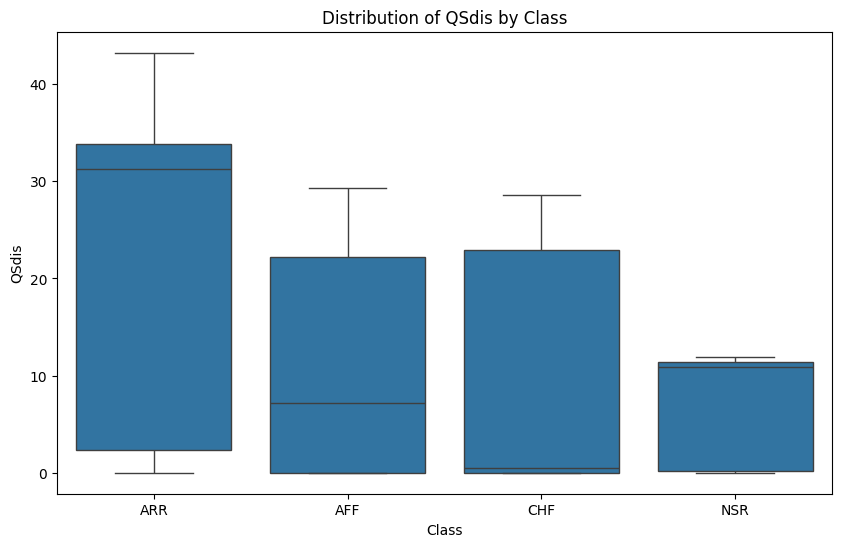

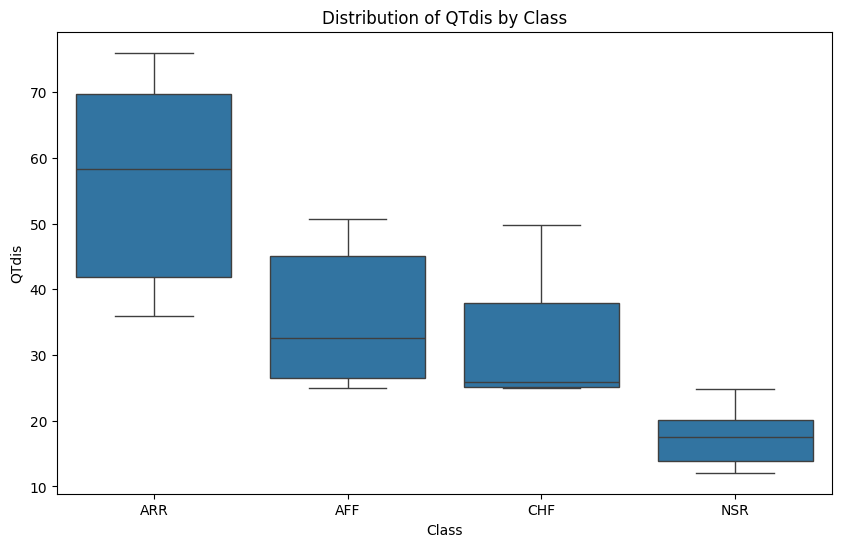

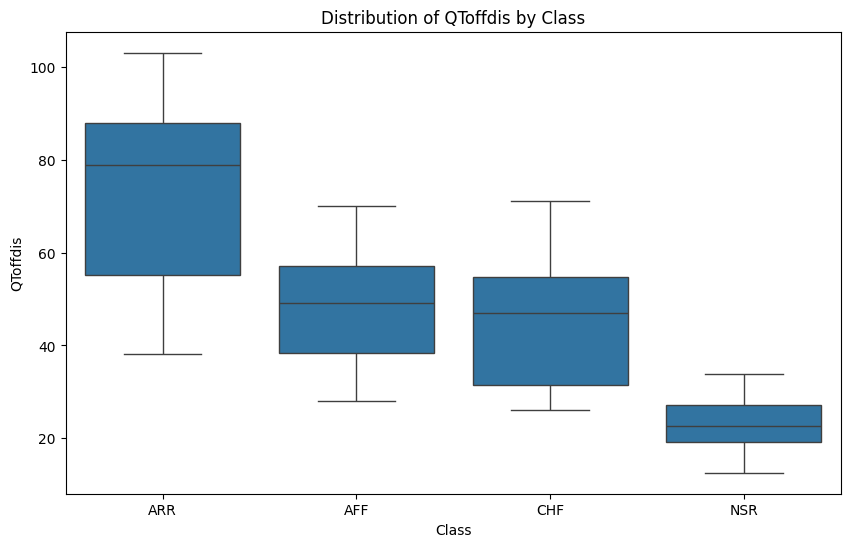

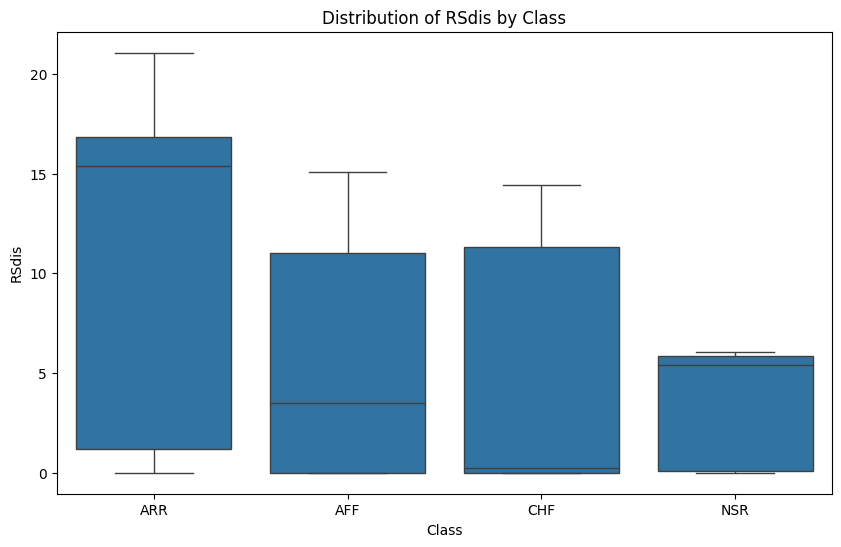

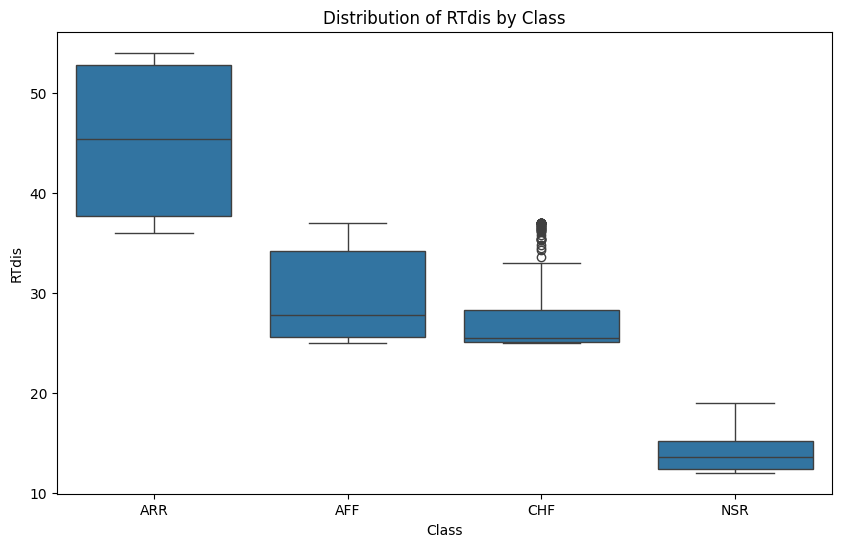

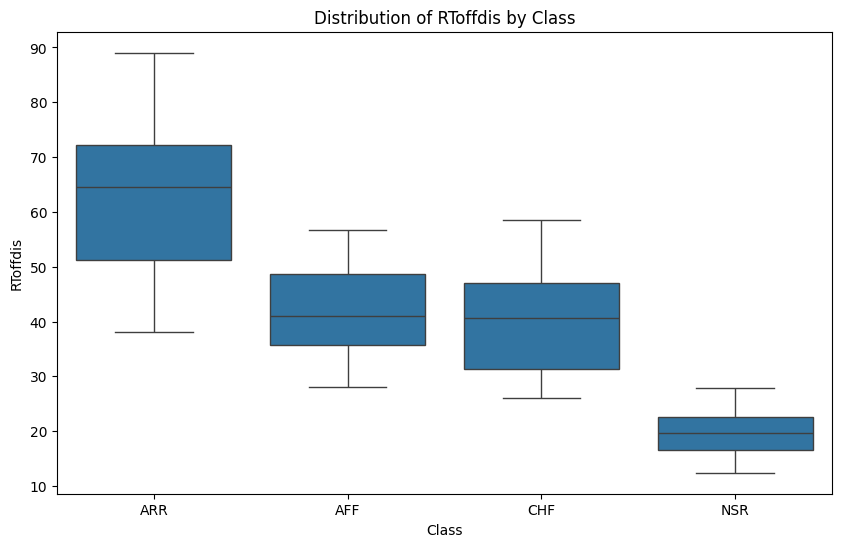

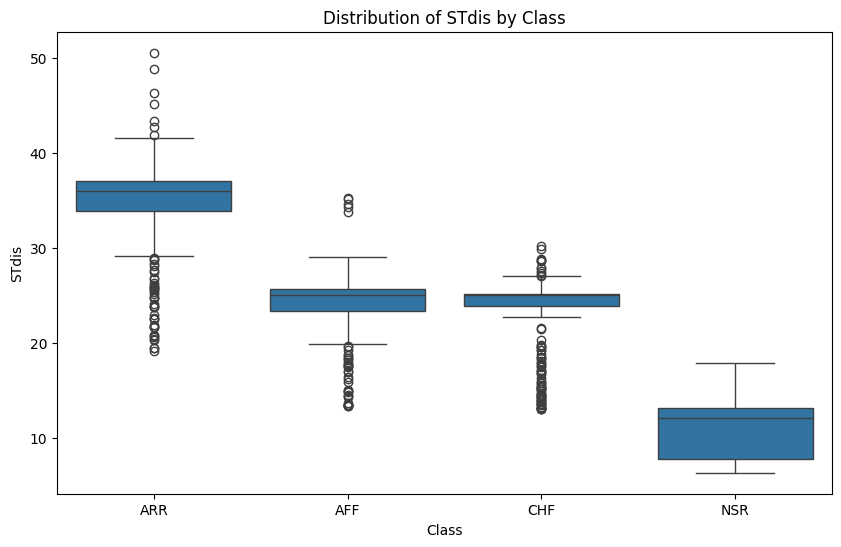

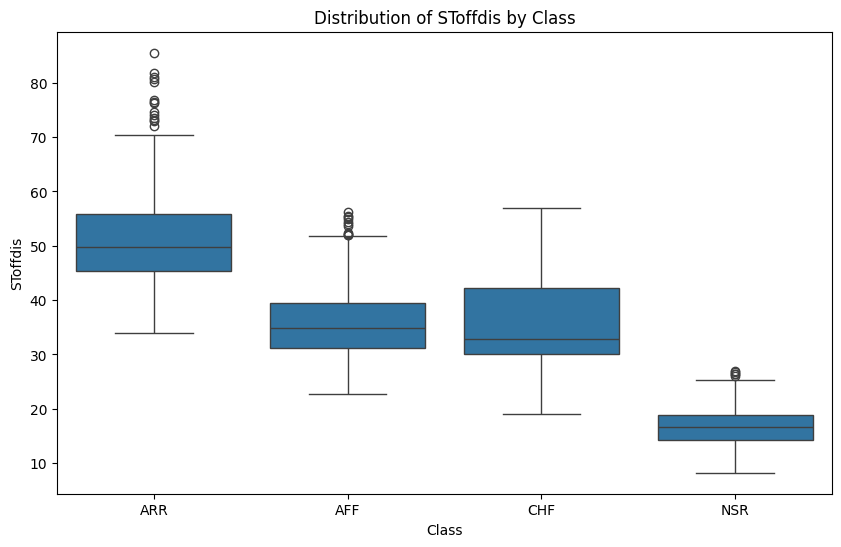

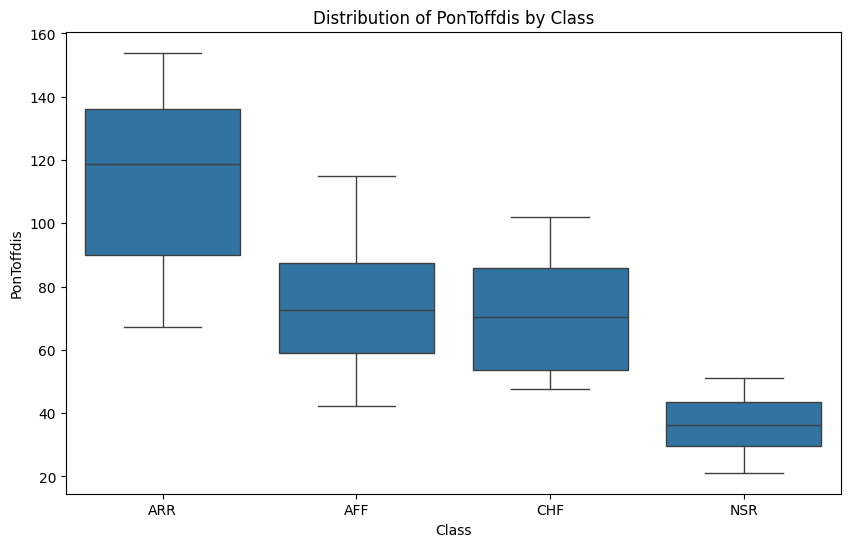

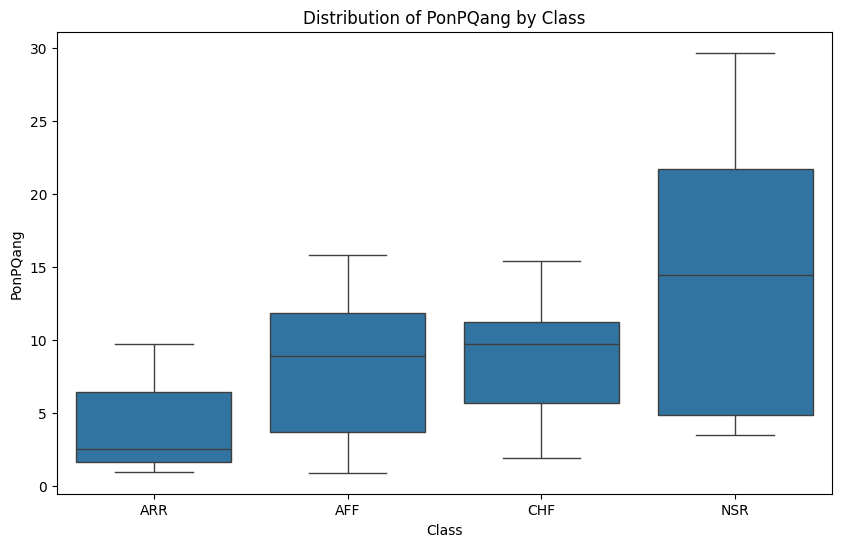

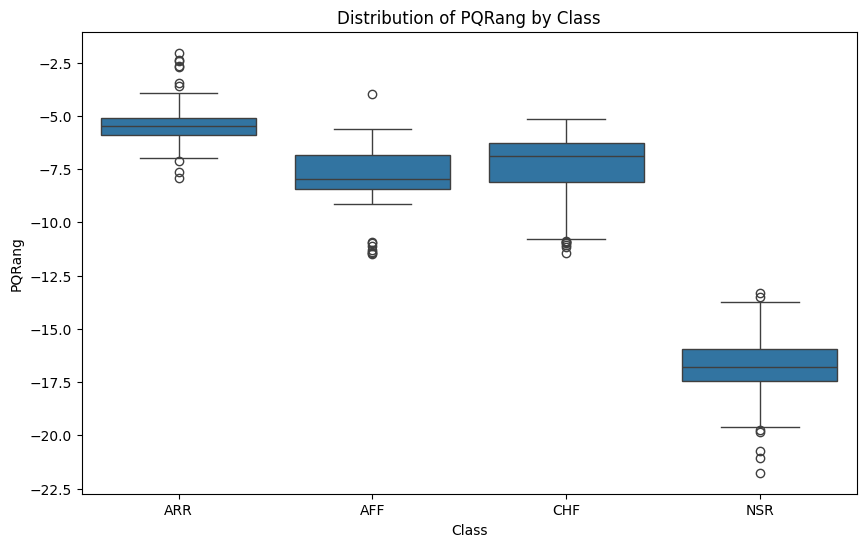

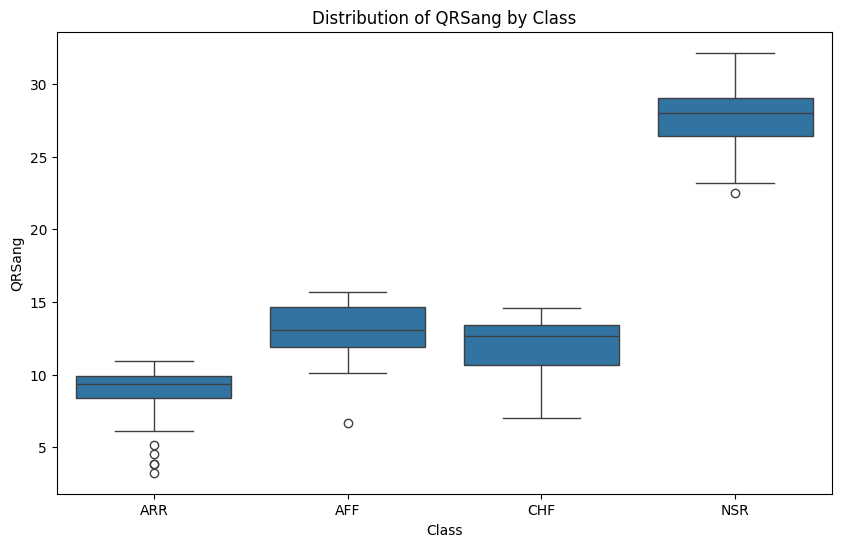

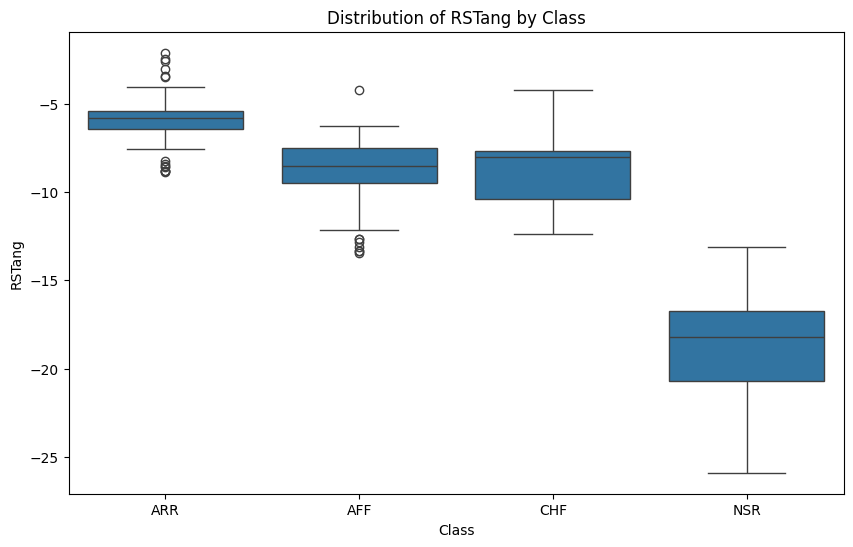

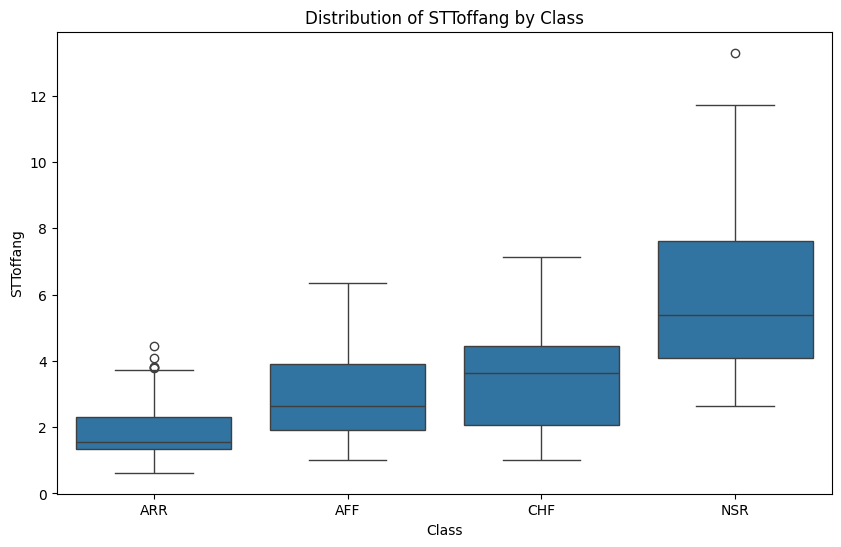

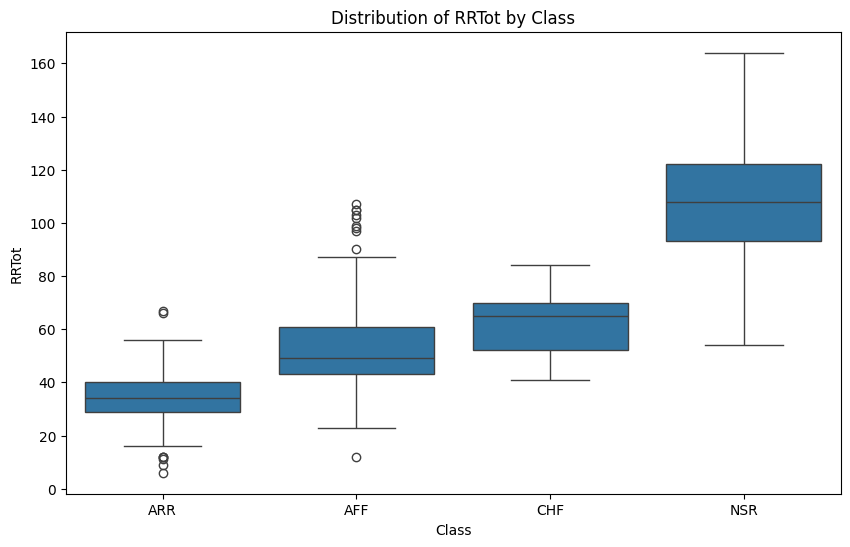

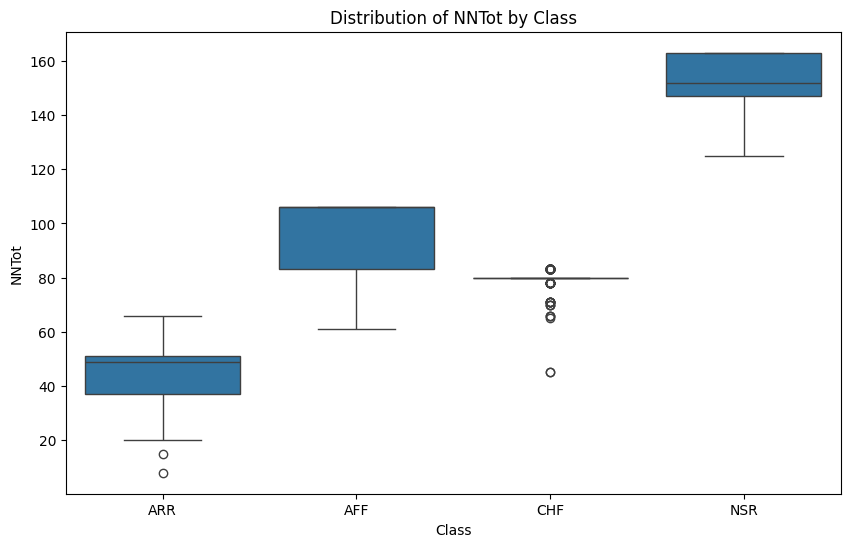

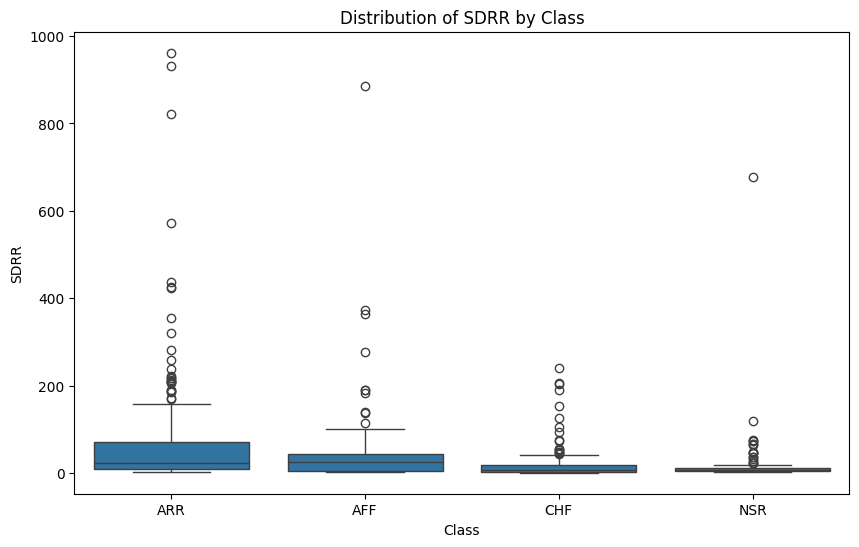

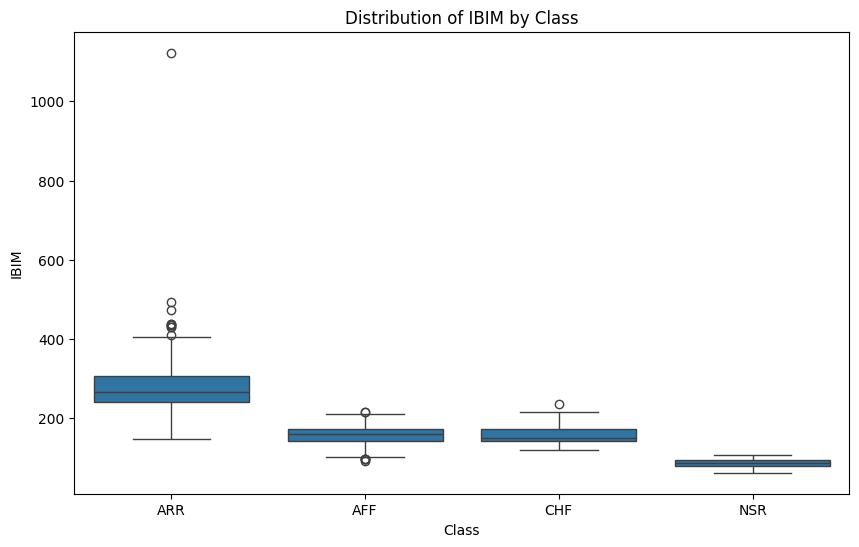

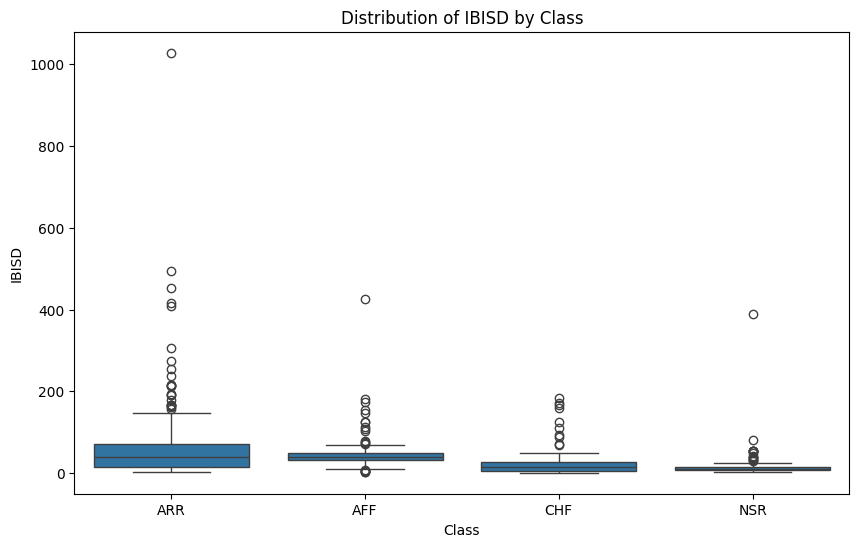

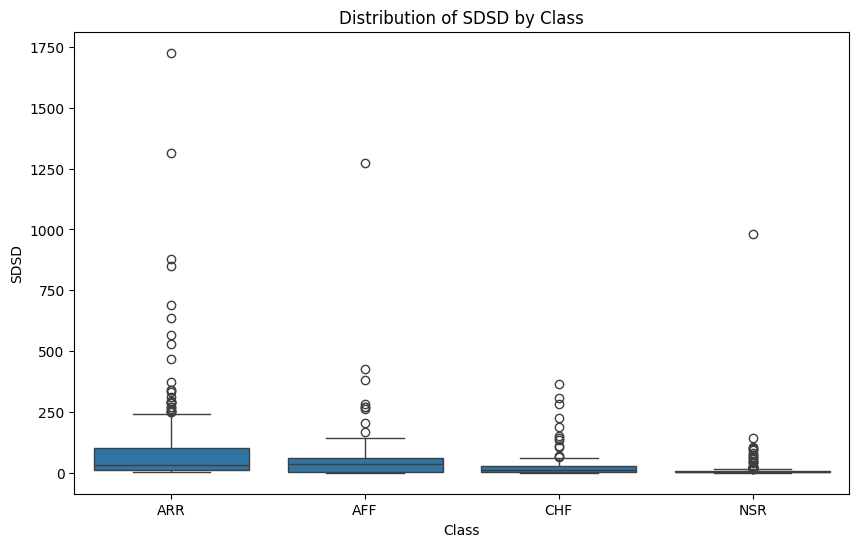

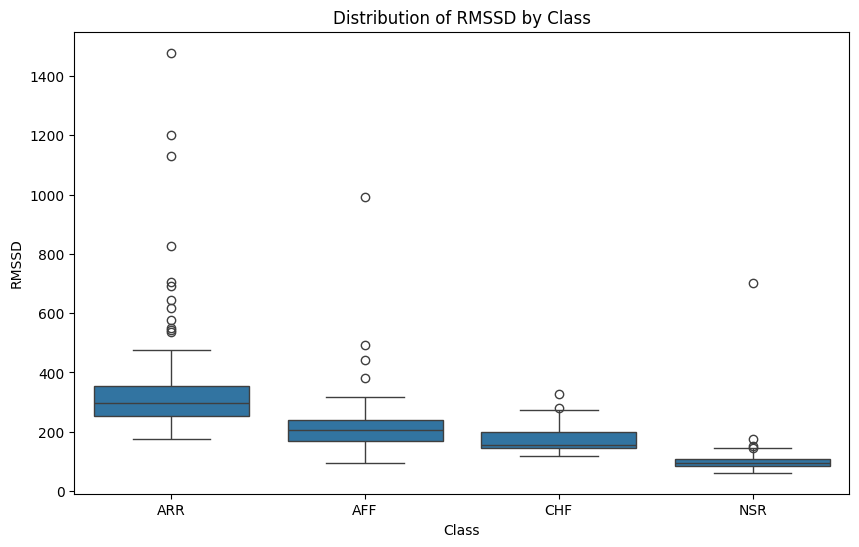

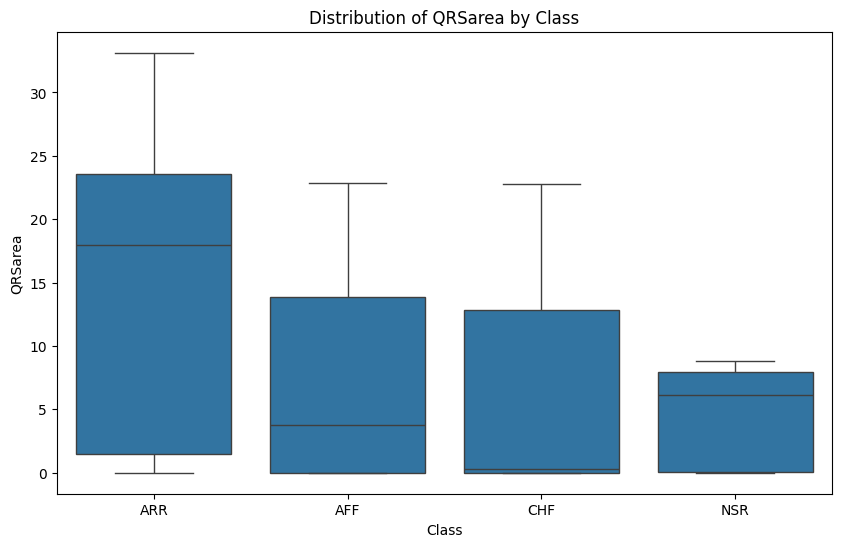

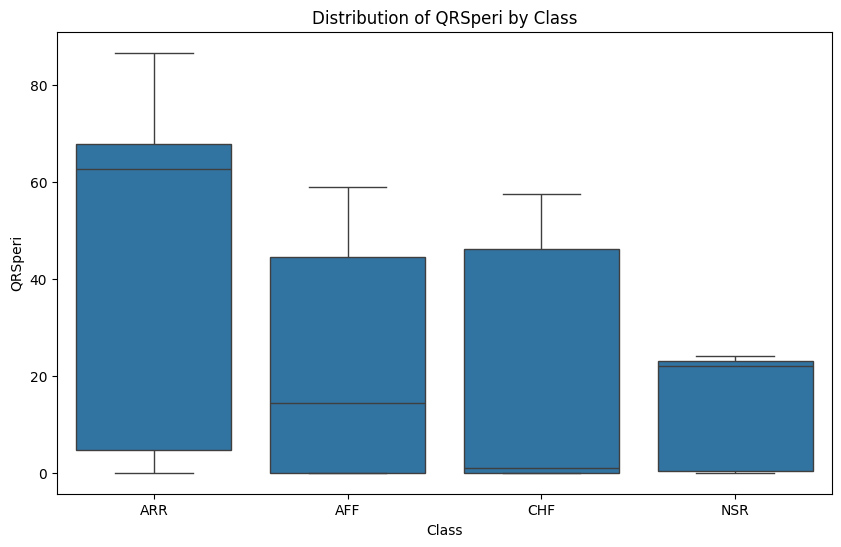

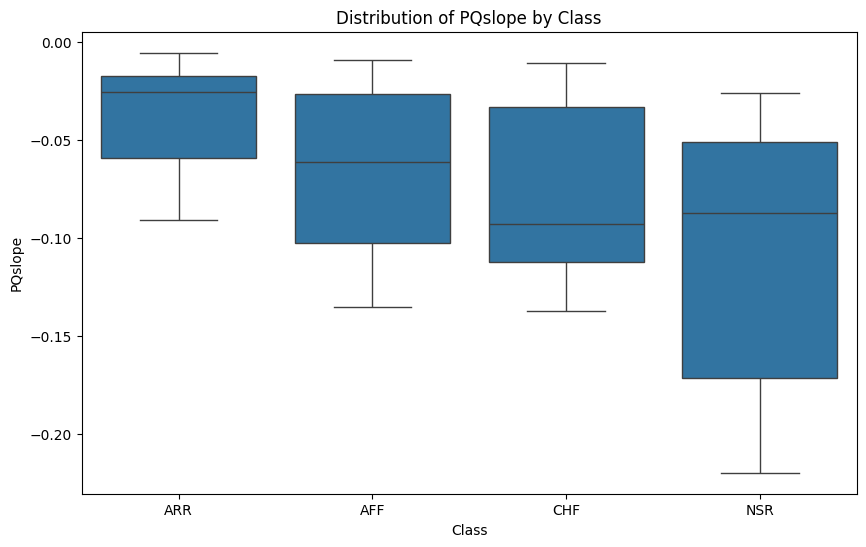

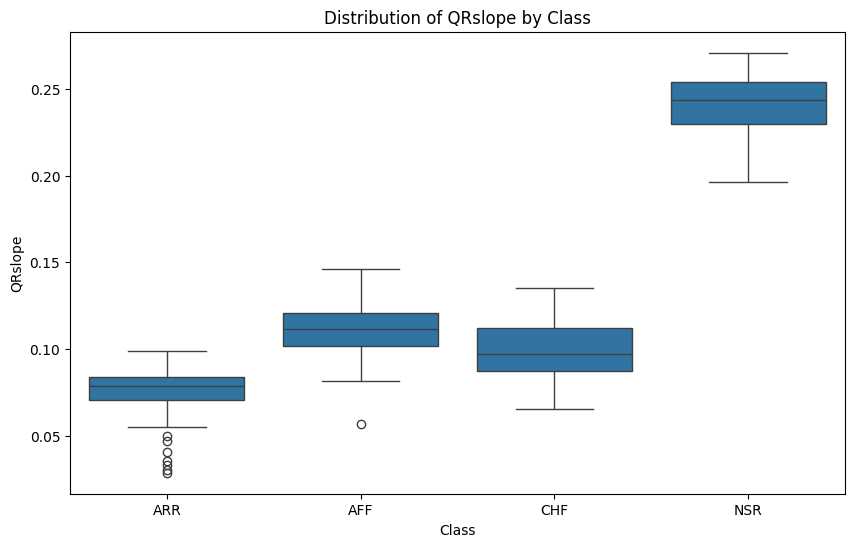

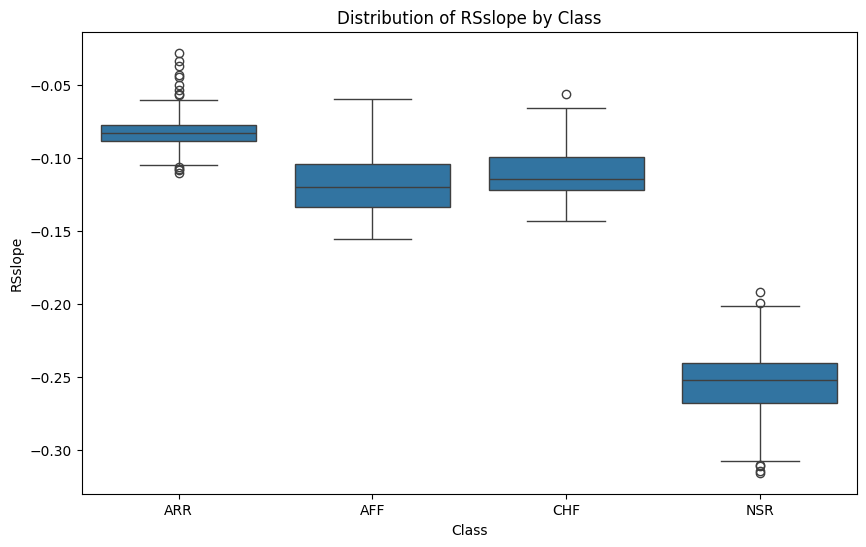

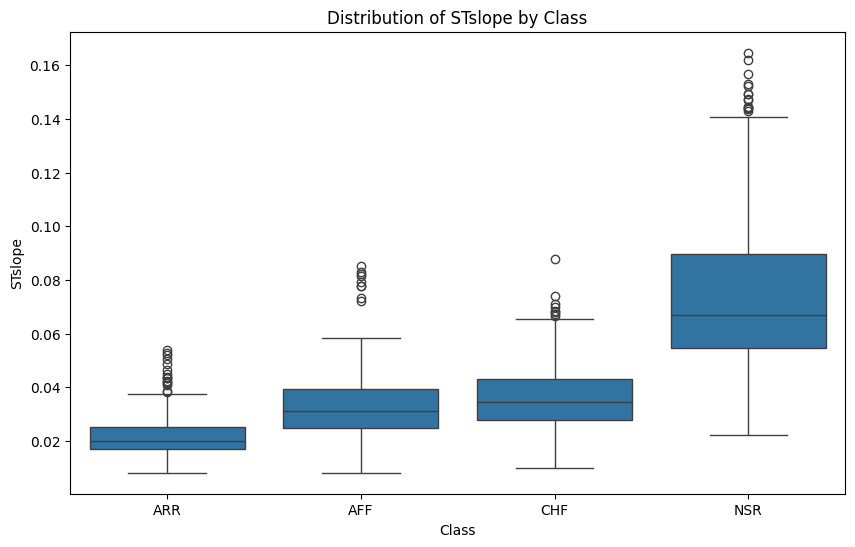

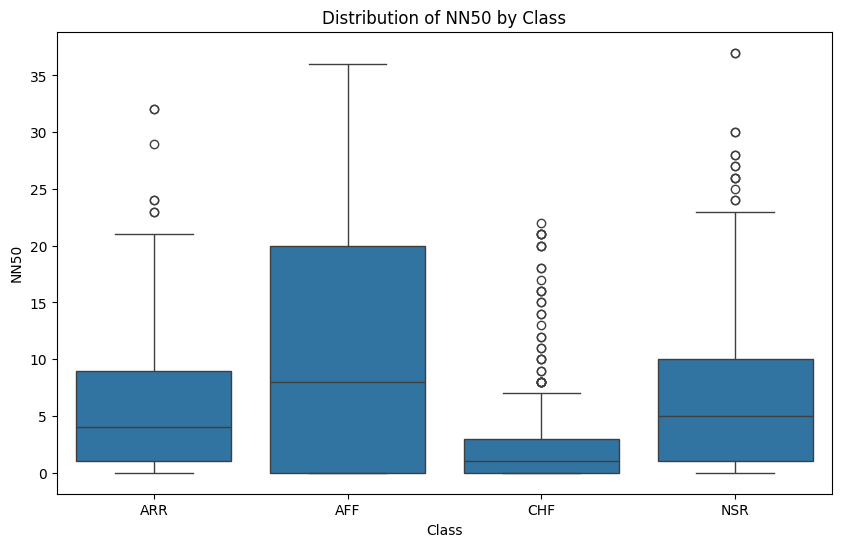

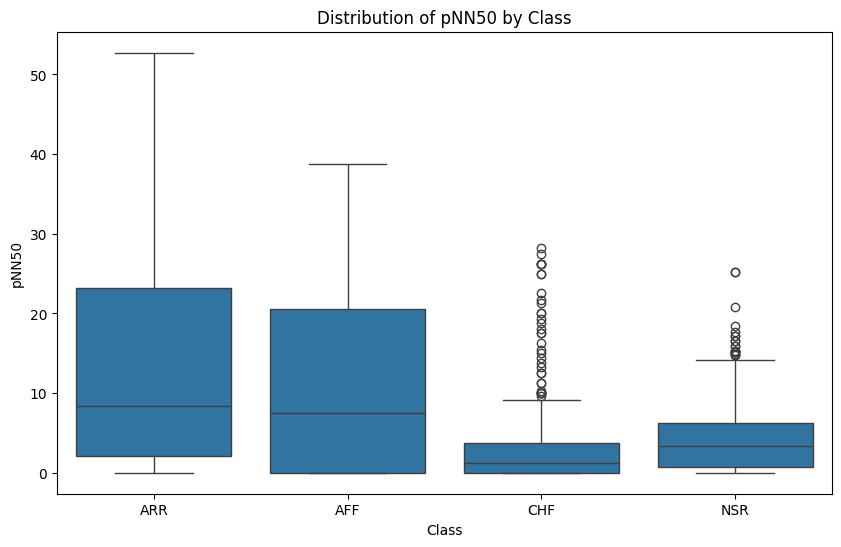

In [31]:
for column in data.columns[1:-1]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='ECG_signal', y=column, data=data)
    plt.title(f'Distribution of {column} by Class')
    plt.xlabel('Class')
    plt.ylabel(column)
    plt.show()


In [32]:
# Identify columns with missing values
missing_columns = ['QRtoQSdur', 'RStoQSdur', 'PonPQang', 'PQRang', 'QRSang', 'RSTang', 'STToffang', 'QRslope', 'RSslope']

# Perform class-wise median imputation
for column in missing_columns:
    for cls in data['ECG_signal'].unique():
        median_value = data.loc[data['ECG_signal'] == cls, column].median()
        data.loc[(data['ECG_signal'] == cls) & (data[column].isnull()), column] = median_value

# Check if all missing values have been handled
missing_values_after_imputation = data.isnull().sum()
missing_values_after_imputation[missing_values_after_imputation > 0]


Series([], dtype: int64)

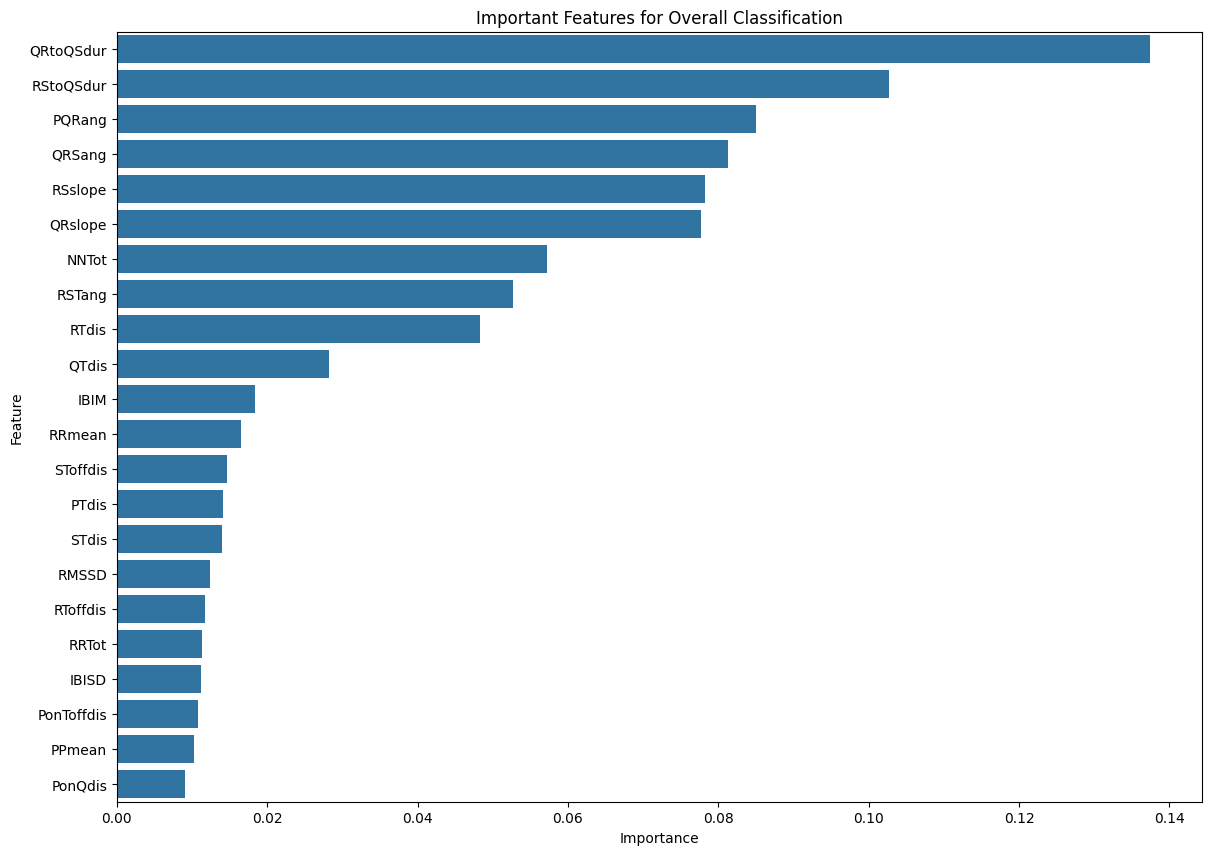

In [33]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Impute missing values
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data.iloc[:, 1:-1]), columns=data.columns[1:-1])

# Encode the target variable
label_encoder = LabelEncoder()
data['ECG_signal_encoded'] = label_encoder.fit_transform(data['ECG_signal'])

# Split the data into training and testing sets
X = data_imputed
y = data['ECG_signal_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Get feature importance
feature_importances = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(14, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(22))
plt.title('Important Features for Overall Classification')
plt.show()


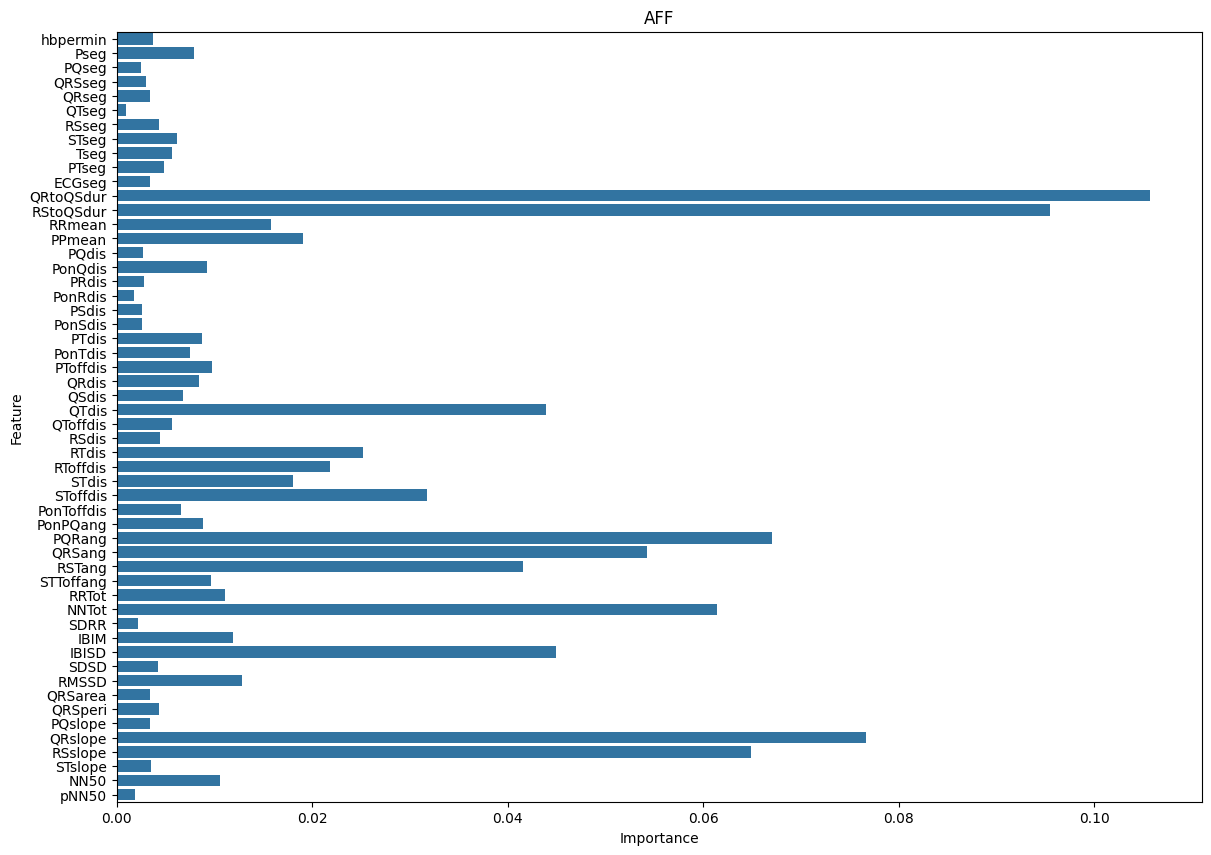

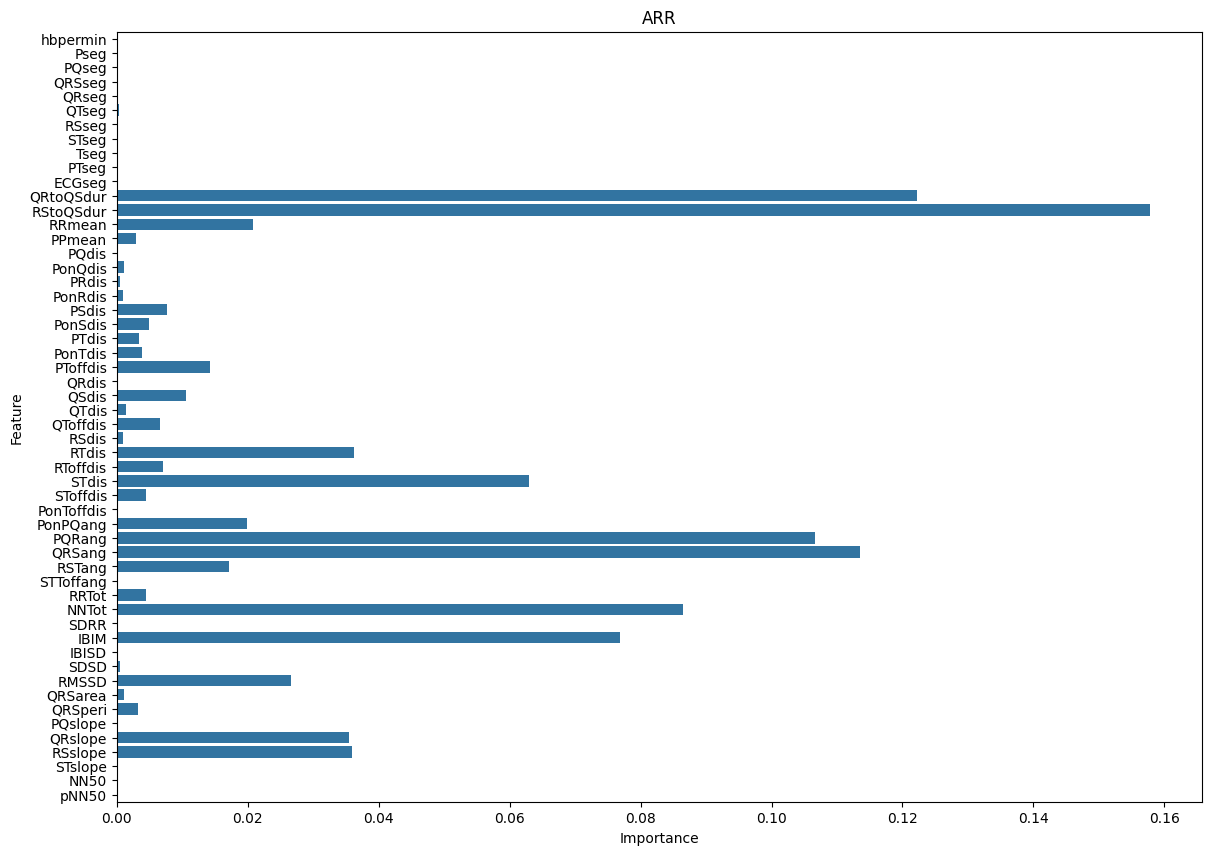

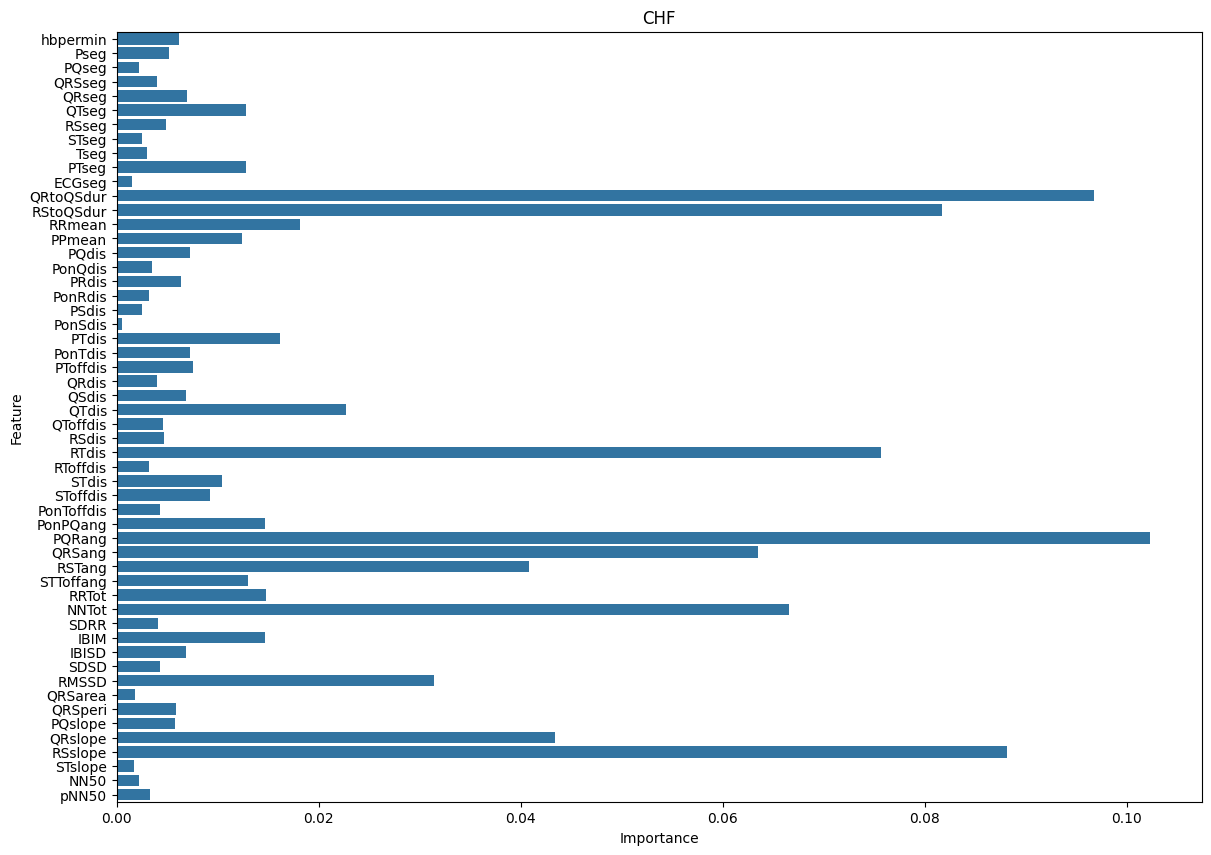

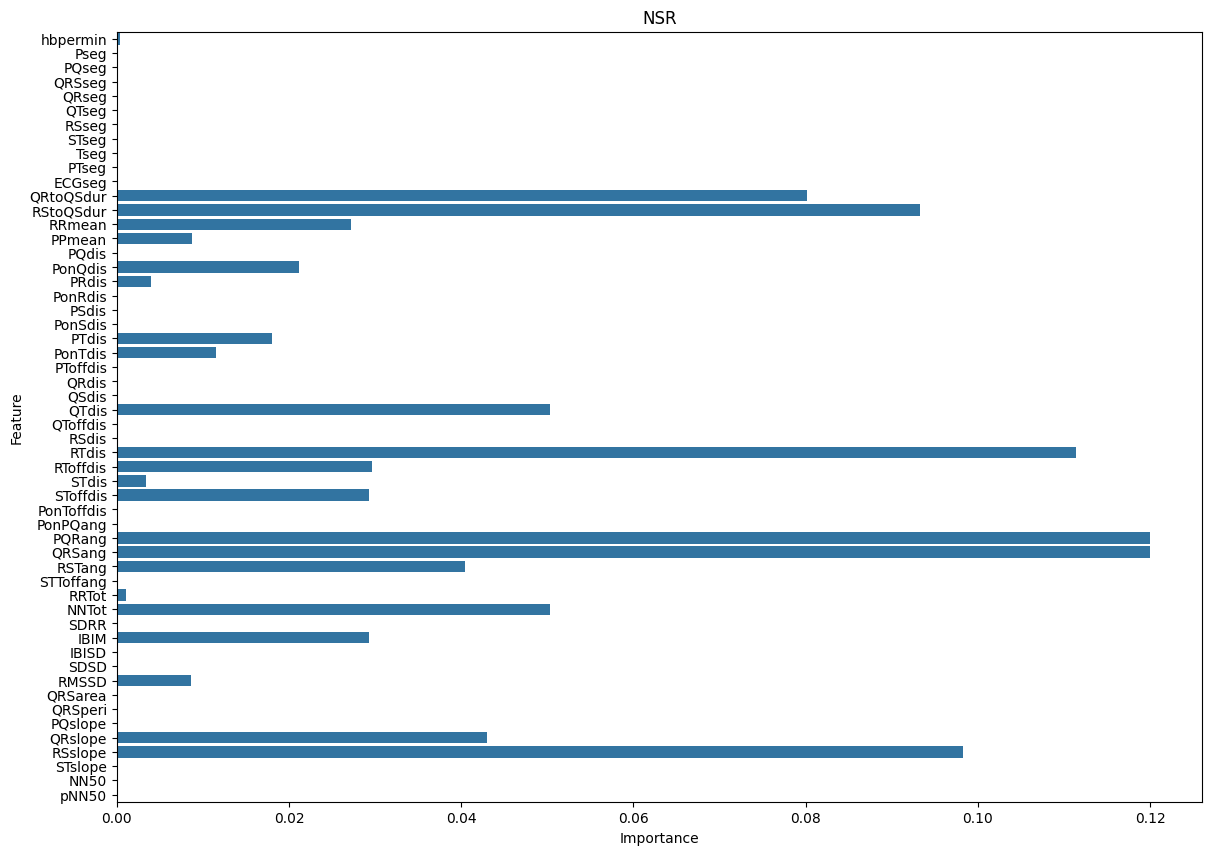

In [34]:

from sklearn.multiclass import OneVsRestClassifier

# Train OvR Random Forest classifiers
ovr_classifier = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovr_classifier.fit(X_train, y_train)

# Get class-wise feature importances
class_feature_importances = {}
for i, class_label in enumerate(label_encoder.classes_):
    class_importances = ovr_classifier.estimators_[i].feature_importances_
    class_feature_importances[class_label] = class_importances

# Convert to DataFrame for easier visualization
class_feature_importance_df = pd.DataFrame(class_feature_importances, index=X.columns)

# Plot class-wise feature importances for each class
for class_label in label_encoder.classes_:
    plt.figure(figsize=(14, 10))
    sns.barplot(x=class_feature_importance_df[class_label], y=class_feature_importance_df.index)
    plt.title(f'{class_label}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
    plt.savefig('example_plot.png')
    plt.close()

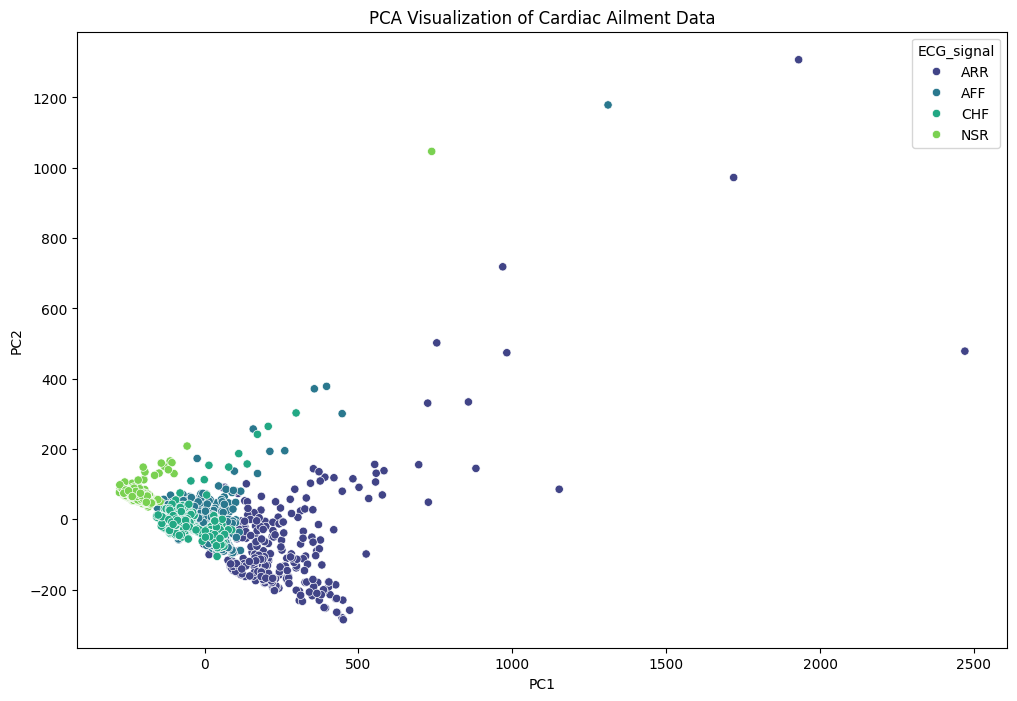

In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Encode target labels
le = LabelEncoder()
data['ECG_signal_encoded'] = le.fit_transform(data['ECG_signal'])

# Prepare data for Random Forest
X = data.drop(columns=['RECORD', 'ECG_signal', 'ECG_signal_encoded'])
y = data['ECG_signal_encoded']

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['ECG_signal'] = data['ECG_signal']

# Plot PCA results
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='ECG_signal', data=pca_df, palette='viridis')
plt.title('PCA Visualization of Cardiac Ailment Data')
plt.show()

In [36]:
import pandas as pd

# Calculate the maximum feature importance across all classes for each feature
max_importances = class_feature_importance_df.max(axis=1)

# Identify columns with a maximum importance greater than 0.02
important_columns = max_importances[max_importances > 0.02].index.tolist()

# Filter the original data DataFrame to retain only the important columns
filtered_data = data[important_columns]
filtered_data['ECG_signal'] = data['ECG_signal']
# Display the filtered DataFrame
print(filtered_data.head())


   QRtoQSdur  RStoQSdur      RRmean    PonQdis      QTdis      RTdis  \
0   0.001371   0.001406  291.794118  55.148893  69.501920  53.827711   
1   0.001368   0.001409  318.387097  46.487006  69.648183  52.973059   
2   0.001397   0.001381  259.763158  42.537823  48.013021  41.142777   
3   0.001390   0.001388  312.838710  54.777178  67.970906  51.684188   
4   0.001359   0.001419  260.783784  49.974799  69.758819  51.976614   

    RToffdis      STdis   SToffdis    PQRang     QRSang    RSTang  NNTot  \
0  83.091597  37.738343  67.001231 -5.127081   8.356354 -4.774444     34   
1  68.682955  35.811162  51.518178 -6.003337   9.217430 -5.355692     31   
2  56.664243  33.408047  48.926073 -5.480068   9.337516 -5.833534     38   
3  63.232731  35.424510  46.970449 -6.253180  10.293861 -6.035961     31   
4  67.409454  33.382822  48.812632 -4.646931   7.254628 -4.489193     37   

         IBIM      IBISD       RMSSD   QRslope   RSslope ECG_signal  
0  291.794118  17.389965  292.296636  0.

<ipython-input-36-fa21255077d4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ECG_signal'] = data['ECG_signal']


In [37]:
# Drop the 'RECORD' and 'ECG_signal_encoded' columns
data_rounded = filtered_data
# Round off all feature columns to two decimal points
feature_columns = data_rounded.columns[:-1]  # Exclude the target column ('ECG_signal')
data_rounded[feature_columns] = data_rounded[feature_columns].round(3)


data_rounded.head()

<ipython-input-37-d71c31a6e515>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rounded[feature_columns] = data_rounded[feature_columns].round(3)


,QRtoQSdur,RStoQSdur,RRmean,PonQdis,QTdis,RTdis,RToffdis,STdis,SToffdis,PQRang,QRSang,RSTang,NNTot,IBIM,IBISD,RMSSD,QRslope,RSslope,ECG_signal
0,0.001,0.001,291.794,55.149,69.502,53.828,83.092,37.738,67.001,-5.127,8.356,-4.774,34,291.794,17.390,292.297,0.075,-0.071,ARR
1,0.001,0.001,318.387,46.487,69.648,52.973,68.683,35.811,51.518,-6.003,9.217,-5.356,31,318.387,10.788,318.564,0.084,-0.077,ARR
2,0.001,0.001,259.763,42.538,48.013,41.143,56.664,33.408,48.926,-5.480,9.338,-5.834,38,259.763,85.647,273.165,0.079,-0.083,ARR
3,0.001,0.001,312.839,54.777,67.971,51.684,63.233,35.425,46.970,-6.253,10.294,-6.036,31,312.839,11.605,313.047,0.092,-0.089,ARR
4,0.001,0.001,260.784,49.975,69.759,51.977,67.409,33.383,48.813,-4.647,7.255,-4.489,37,260.784,36.265,263.226,0.065,-0.062,ARR


In [38]:

# Create a new column 'text' which contains the string representation of each row
data_rounded['text'] = data_rounded.apply(lambda row: ', '.join(f"{col}: {row[col]}" for col in feature_columns), axis=1)

# Select only the 'text' and 'ECG_signal' columns
data_text = data_rounded[['text', 'ECG_signal']]

# Convert 'text' and 'ECG_signal' columns to string explicitly
data_text.loc[:, 'text'] = data_text['text'].astype(str)
data_text.loc[:, 'ECG_signal'] = data_text['ECG_signal'].astype(str)

data_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        1200 non-null   object
 1   ECG_signal  1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB


<ipython-input-38-d128254b2b37>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rounded['text'] = data_rounded.apply(lambda row: ', '.join(f"{col}: {row[col]}" for col in feature_columns), axis=1)


In [39]:
# Display a few examples
data_text.head()

,text,ECG_signal
0,"QRtoQSdur: 0.001, RStoQSdur: 0.001, RRmean: 29...",ARR
1,"QRtoQSdur: 0.001, RStoQSdur: 0.001, RRmean: 31...",ARR
2,"QRtoQSdur: 0.001, RStoQSdur: 0.001, RRmean: 25...",ARR
3,"QRtoQSdur: 0.001, RStoQSdur: 0.001, RRmean: 31...",ARR
4,"QRtoQSdur: 0.001, RStoQSdur: 0.001, RRmean: 26...",ARR


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert categorical labels to numbers
label_encoder = LabelEncoder()

# Use .loc to ensure the operation is performed on the DataFrame directly
data_text.loc[:, 'ECG_signal'] = label_encoder.fit_transform(data_text['ECG_signal'])

# Split the dataset
train_df, test_df = train_test_split(data_text, test_size=0.2, random_state=42)

# Extracting text and labels
train_texts = train_df['text'].tolist()
train_labels = train_df['ECG_signal'].tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['ECG_signal'].tolist()

In [41]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)  # Adjust number of labels

# Tokenize data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# Convert to torch tensors
train_seq = torch.tensor(train_encodings['input_ids'])
train_mask = torch.tensor(train_encodings['attention_mask'])
train_y = torch.tensor(train_labels)

test_seq = torch.tensor(test_encodings['input_ids'])
test_mask = torch.tensor(test_encodings['attention_mask'])
test_y = torch.tensor(test_labels)

# Data loaders
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = torch.utils.data.RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=2)

test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=4)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
import torch
from transformers import AdamW

if torch.cuda.is_available():
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available.")

optimizer = AdamW(model.parameters(), lr=2e-5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 5
train_loss_steps = []
val_loss_steps = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    steps = 0
    for batch in train_dataloader:
        b_input_ids, b_input_mask, b_labels = batch
        b_input_ids = b_input_ids.to(device)
        b_input_mask = b_input_mask.to(device)
        b_labels = b_labels.to(device)

        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps += 1
        train_loss_steps.append(loss.item())
        print(f"Epoch {epoch + 1}, Step {steps}, Train Loss: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_dataloader)
    print(f"End of Epoch {epoch + 1}: Average Train Loss: {avg_train_loss:.4f}")

CUDA is available. GPU: Tesla T4


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1, Step 1, Train Loss: 0.8415
Epoch 1, Step 2, Train Loss: 1.6673
Epoch 1, Step 3, Train Loss: 2.4139
Epoch 1, Step 4, Train Loss: 1.3555
Epoch 1, Step 5, Train Loss: 1.2785
Epoch 1, Step 6, Train Loss: 1.5236
Epoch 1, Step 7, Train Loss: 1.5178
Epoch 1, Step 8, Train Loss: 1.3378
Epoch 1, Step 9, Train Loss: 1.7327
Epoch 1, Step 10, Train Loss: 1.5054
Epoch 1, Step 11, Train Loss: 1.2046
Epoch 1, Step 12, Train Loss: 1.3055
Epoch 1, Step 13, Train Loss: 1.5012
Epoch 1, Step 14, Train Loss: 1.3640
Epoch 1, Step 15, Train Loss: 1.4400
Epoch 1, Step 16, Train Loss: 1.1897
Epoch 1, Step 17, Train Loss: 1.2506
Epoch 1, Step 18, Train Loss: 1.5832
Epoch 1, Step 19, Train Loss: 1.6257
Epoch 1, Step 20, Train Loss: 1.6467
Epoch 1, Step 21, Train Loss: 1.6635
Epoch 1, Step 22, Train Loss: 1.3531
Epoch 1, Step 23, Train Loss: 1.4028
Epoch 1, Step 24, Train Loss: 1.7494
Epoch 1, Step 25, Train Loss: 1.2976
Epoch 1, Step 26, Train Loss: 1.5249
Epoch 1, Step 27, Train Loss: 1.3372
Epoch 1, S

In [45]:
model.save_pretrained('./my_ecg_filtered_classifier')
tokenizer.save_pretrained('./my_ecg_filtered_classifier')

('./my_ecg_filtered_classifier/tokenizer_config.json',
 './my_ecg_filtered_classifier/special_tokens_map.json',
 './my_ecg_filtered_classifier/vocab.txt',
 './my_ecg_filtered_classifier/added_tokens.json')

In [47]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification

# Load model and tokenizer
model_path = './my_ecg_filtered_classifier'
model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained(model_path)

test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)
test_seq = torch.tensor(test_encodings['input_ids'])
test_mask = torch.tensor(test_encodings['attention_mask'])
test_y = torch.tensor(test_labels)

# DataLoader
from torch.utils.data import DataLoader, TensorDataset
test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=2)

# Evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_input_mask, b_labels = batch
        b_input_ids = b_input_ids.to(device)
        b_input_mask = b_input_mask.to(device)
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        # Move logits and labels to CPU
        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Store predictions and true labels
        predictions.append(np.argmax(logits, axis=1))
        true_labels.append(label_ids)

# Flatten the lists
predictions = [item for sublist in predictions for item in sublist]
true_labels = [item for sublist in true_labels for item in sublist]

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f'Accuracy: {accuracy}')
print(classification_report(true_labels, predictions))

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)


Accuracy: 0.9958333333333333
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      1.00      1.00        62
           2       1.00      0.98      0.99        60
           3       1.00      1.00      1.00        58

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



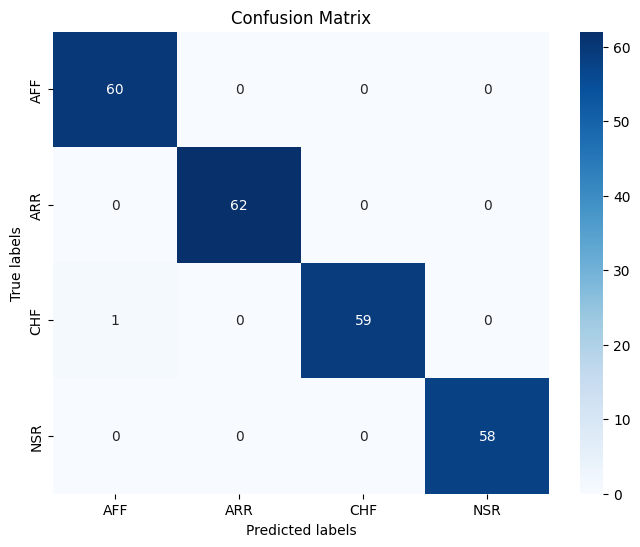

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# Assume label_encoder is defined and used as shown in previous sections
# Save label names for later use in plotting
label_names = label_encoder.classes_

# Convert numeric labels back to original text labels for plotting
predicted_labels = [label_names[label] for label in predictions]
true_labels_text = [label_names[label] for label in true_labels]

# Compute confusion matrix
cm = confusion_matrix(true_labels_text, predicted_labels, labels=label_names)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

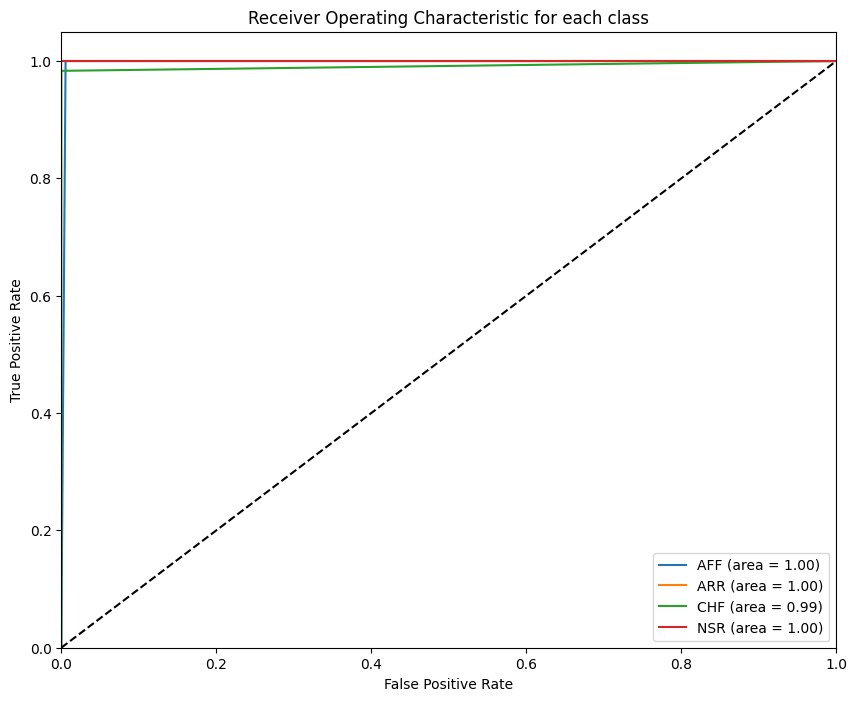

In [49]:
from sklearn.preprocessing import label_binarize

# Binarize labels
y_bin = label_binarize(true_labels_text, classes=label_names)
predictions_bin = label_binarize(predicted_labels, classes=label_names)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i, label in enumerate(label_names):
    fpr[label], tpr[label], _ = roc_curve(y_bin[:, i], predictions_bin[:, i])
    roc_auc[label] = auc(fpr[label], tpr[label])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for label in label_names:
    plt.plot(fpr[label], tpr[label], label=f'{label} (area = {roc_auc[label]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for each class')
plt.legend(loc="lower right")
plt.show()


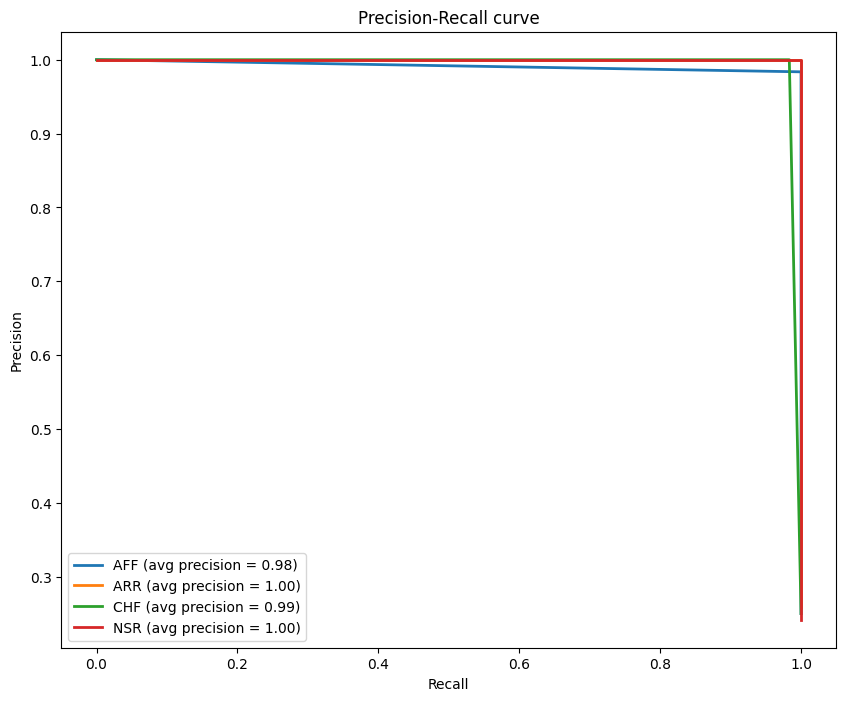

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Assuming y_bin and predictions_bin are already computed as shown previously
precision = dict()
recall = dict()
average_precision = dict()
for i, label in enumerate(label_names):
    precision[label], recall[label], _ = precision_recall_curve(y_bin[:, i], predictions_bin[:, i])
    average_precision[label] = average_precision_score(y_bin[:, i], predictions_bin[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(10, 8))
for label in label_names:
    plt.plot(recall[label], precision[label], lw=2, label=f'{label} (avg precision = {average_precision[label]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc="best")
plt.show()
